# Acoplador Direcional

Este experimento ocorrerá em quatro etapas:

I - Criação do modelo do dispositivo

II - Solução dos modos por FDE

III - Solução dos modos por FDTD resultando em uma matriz de parâmetros S para o dispositivo

IV - Utilização do dispositivo no INTERCONNECT

## I - Criação do modelo do dispositivo

In [5]:
# Bibliotecas

import sys, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.constants import c, pi, lambda2nu, nu2lambda

sys.path.append("C:\\Program Files\\Lumerical\\v221\\api\\python\\")
import lumapi

import h5py

In [18]:
# Definindo as variáveis de interesse:

# Materiais:
material_dispositivo = "Si (Silicon) - Palik"
material_substrato = "SiO2 (Silicon Dioxide) - Palik"

# Medidas básicas do dispositivo:
curvatura = 10e-6 # Curvatura dos guias esquerdo (L) e direito (R) (fixo)
largura_guia = 0.45e-6 #                                           (fixo)
altura_guia = 0.22e-6  #                                           (fixo)

gap = 0.2e-6 # Distância entre os guias                            (variável)
Lc = 5e-6 # Comprimento da região de acoplamento                   (variável)

# Variáveis FDE: --------------------------------------------------------------
bSolver = 2*largura_guia + gap
hSolver = altura_guia
y_solver = 0 
fator_m_malha = 2 # Fator inicial na análise de convergência da malha
bc = "Metal" # Condição de contorno


# Variáveis FDTD: --------------------------------------------------------------
comprimento_guias_portas = 2e-6 


In [19]:
# Modularização dos métodos:

def resetar_layout(solver):
    solver.switchtolayout()
    solver.deleteall()


def criar_acopladorDirecional(solver, Pmaterial, Pcurvatura, Paltura_guia, Plargura_guia, Pgap, PLc, Pcomprimento_guias_portas):
    y_guias_curvos = Pcurvatura + Plargura_guia/2 + Pgap/2
    y_guias_retos = (Plargura_guia + Pgap)/2

    x_portas_inferiores = Pcurvatura + PLc/2 + Pcomprimento_guias_portas/2
    x_portas_superiores = Pcurvatura + PLc/2
    y_portas_inferiores = y_guias_retos
    y_portas_superiores = (Plargura_guia + Pgap)/2 + Pcurvatura + Pcomprimento_guias_portas/2

    solver.addobject("90_bend_wg")  
    solver.set("name", "R")
    solver.set("material", Pmaterial)
    solver.set("radius", Pcurvatura)
    solver.set("first axis", "z")
    solver.set("rotation 1", -90)
    solver.set("base height", Paltura_guia)
    solver.set("base width", Plargura_guia)
    solver.set("x",Lc/2)
    solver.set("y",y_guias_curvos)
    solver.set("z",0)

    solver.addobject("90_bend_wg")
    solver.set("name", "L")
    solver.set("material", Pmaterial)
    solver.set("radius", Pcurvatura)
    solver.set("first axis", "z")
    solver.set("rotation 1", 180)
    solver.set("base height", Paltura_guia)
    solver.set("base width", Plargura_guia)
    solver.set("x",-PLc/2)
    solver.set("y",y_guias_curvos)
    solver.set("z",0)

    solver.addrect()
    solver.set("name", "Lc")
    solver.set("material", Pmaterial)
    solver.set("x",0)
    solver.set("y",y_guias_retos)
    solver.set("z",0)
    solver.set("y span", Plargura_guia)
    solver.set("x span", PLc)
    solver.set("z span", Paltura_guia)

    solver.addrect()
    solver.set("name", "wg")
    solver.set("material", Pmaterial)
    solver.set("x",0)
    solver.set("y",-y_guias_retos)
    solver.set("z",0)
    solver.set("y span", Plargura_guia)
    solver.set("x span", PLc+2*Pcurvatura)
    solver.set("z span", Paltura_guia)

    solver.addrect()
    solver.set("material", Pmaterial)
    solver.set("name", "porta1")
    solver.set("x span", Pcomprimento_guias_portas)
    solver.set("z span", Paltura_guia)
    solver.set("y span", Plargura_guia)
    solver.set("x", x_portas_inferiores)
    solver.set("y", -1*y_portas_inferiores)
    solver.set("z", 0)

    solver.addrect()
    solver.set("material", Pmaterial)
    solver.set("name", "porta2")
    solver.set("x span", Pcomprimento_guias_portas)
    solver.set("z span", Paltura_guia)
    solver.set("y span", Plargura_guia)
    solver.set("x", -1*x_portas_inferiores)
    solver.set("y", -1*y_portas_inferiores)
    solver.set("z", 0)

    solver.addrect()
    solver.set("material", Pmaterial)
    solver.set("name", "porta3")
    solver.set("x span", Plargura_guia)
    solver.set("z span", Paltura_guia)
    solver.set("y span", Pcomprimento_guias_portas)
    solver.set("x", x_portas_superiores)
    solver.set("y", y_portas_superiores)
    solver.set("z", 0)

    solver.addrect()
    solver.set("material", Pmaterial)
    solver.set("name", "porta4")
    solver.set("x span", Plargura_guia)
    solver.set("z span", Paltura_guia)
    solver.set("y span", Pcomprimento_guias_portas)
    solver.set("x", -1*x_portas_superiores)
    solver.set("y", y_portas_superiores)
    solver.set("z", 0)

def atualizar_acopladorDirecional_gap(solver, Pgap):

    solver.switchtolayout()
    solver.select("R")
    solver.set("y",curvatura+largura_guia/2+Pgap/2)
    solver.select("L")
    solver.set("y",curvatura+largura_guia/2+Pgap/2)
    solver.select("Lc")
    solver.set("y",largura_guia/2+Pgap/2)
    solver.select("wg")
    solver.set("y",-largura_guia/2-Pgap/2)
    solver.select("porta1")
    solver.set("y",-largura_guia/2-Pgap/2)
    solver.select("porta2")
    solver.set("y",-largura_guia/2-Pgap/2)
    solver.select("porta3")
    solver.set("y", largura_guia/2+Pgap/2 + comprimento_guias_portas/2 +curvatura)
    solver.select("porta4")
    solver.set("y", largura_guia/2+Pgap/2 + comprimento_guias_portas/2 +curvatura)

def atualizar_acopladorDirecional_Lc(solver, PLc):
    solver.switchtolayout()
    solver.select("R")
    solver.set("x",PLc/2)

    solver.select("L")
    solver.set("x",-PLc/2)

    solver.select("Lc")
    solver.set("x span", PLc)

    solver.select("wg")
    solver.set("x span", PLc+2*curvatura)

    solver.select("porta1")
    solver.set("x", curvatura + PLc/2 + comprimento_guias_portas/2)

    solver.select("porta2")
    solver.set("x", -curvatura - PLc/2 - comprimento_guias_portas/2)
    
    solver.select("porta3")
    solver.set("x", curvatura + PLc/2)

    solver.select("porta4")
    solver.set("x", -curvatura - PLc/2)

def reset_view(solver):
    solver.unselectall()
    solver.setview("extent")
    solver.setview("zoom", 2)


In [13]:
# Iniciando o MODE na variável m
m = lumapi.MODE(hide=False)

In [15]:
resetar_layout(m)
criar_acopladorDirecional(m, material_dispositivo, curvatura, altura_guia, largura_guia, gap, Lc, comprimento_guias_portas)
reset_view(m)

# II - Solução dos modos por FDE

### Criação do SOLVER FDE e malha

O objetivo é avaliar os modos que se propagam em x. Além disso, verificar a convergência em função da malha. 

Para isso, foi implementado o solver 2d com a componente normal à sua superfície alinhada na direção x. Considerou-se as medidadas da largura e altura do guia e a distância inicial do gap para padronizar as dimensões do solver e da malha, que serão em função de $b$ e $h$, sendo:

$b_{solver} = 2\cdot(L_{guia}) + gap$

$h_{solver} = h_{guia}$

O solver será 4 vezes maior, enquanto a malha será 2 vezes maior.

### Análise de convergência

Quanto ao número de células, foi considerado utilizar 50 células no solver e inicialmente um fator multiplicativo de 2 para a malha. A análise de convergência irá testar para outros fatores tomando como base a parte real do índice efetivo dos modos.

A análise foi feita para as condições de fronteira: metal e PML.

In [20]:
def solverFDE(Py_solver,PbSolver,PhSolver,Pbc):
    m.addfde()
    m.set("wavelength", 1.55e-6)
    m.set("background material", "SiO2 (Glass) - Palik")
    m.set("solver type", "2D x normal")
    m.set("x",0)
    m.set("y",Py_solver)
    m.set("z",0)
    m.set("y span", 4*PbSolver)
    m.set("z span", 4*PhSolver)
    m.set("mesh cells y", 50)
    m.set("mesh cells z", 50)
    m.set("y min bc", Pbc)
    m.set("y max bc", Pbc)
    m.set("z min bc", Pbc)
    m.set("z max bc", Pbc)

solverFDE(y_solver,bSolver,hSolver,bc)

def mesh(Py_solver,PbSolver,PhSolver, Pfator_m_malha):
    m.addmesh()
    m.set("x",0)
    m.set("y",Py_solver)
    m.set("z",0)
    m.set("set mesh multiplier", 1)
    m.set("y mesh multiplier", Pfator_m_malha)
    m.set("z mesh multiplier", Pfator_m_malha)
    m.set("x span", 0)
    m.set("y span", 2*PbSolver)
    m.set("z span", 2*PhSolver)

mesh(y_solver,bSolver,hSolver,fator_m_malha)


In [21]:
reset_view(m)

In [22]:
fator_m_malha = range(2,16,1)

def convergencia(Pfator_m_malha, Py_solver,PbSolver,PhSolver,Pneff):
    for i in range(len(Pfator_m_malha)):
        m.switchtolayout()
        m.select("mesh")
        m.delete()
        mesh(Py_solver,PbSolver,PhSolver,Pfator_m_malha[i])
        m.findmodes()
        n = m.getresult(f"FDE::data::mode1", "neff")
        Pneff[i] = np.real(n[0][0])



In [23]:
neff_modo1_METAL = np.zeros(len(fator_m_malha))
convergencia(fator_m_malha, y_solver, bSolver, hSolver, neff_modo1_METAL)
bc = "PML"
m.switchtolayout()
m.select("FDE")
m.delete()
solverFDE(y_solver,bSolver,hSolver,bc)
neff_modo1_PML = np.zeros(len(fator_m_malha))
convergencia(fator_m_malha, y_solver, bSolver, hSolver, neff_modo1_PML)

In [24]:
# Salvar os resultados

with h5py.File("convergencia_malha.h5", "w-") as f:
    f.create_dataset("fator_m_malha", data=fator_m_malha)
    f.create_dataset("neff_modo1_METAL", data=neff_modo1_METAL)
    f.create_dataset("neff_modo1_PML", data=neff_modo1_PML)

In [297]:
def plot_curva_2d(qtd_curvas, dados_x, dados_y, label_x, label_y, legendas_curvas, nome_arquivo):
    plt.figure(figsize=(9, 3))
    for i in range(qtd_curvas):
        plt.plot(dados_x[i], dados_y[i], marker='o', label=legendas_curvas[i])
    plt.xlabel(label_x)
    plt.ylabel(label_y)
    plt.grid()
    plt.legend(loc="lower right", fontsize=10)
    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
    plt.show()

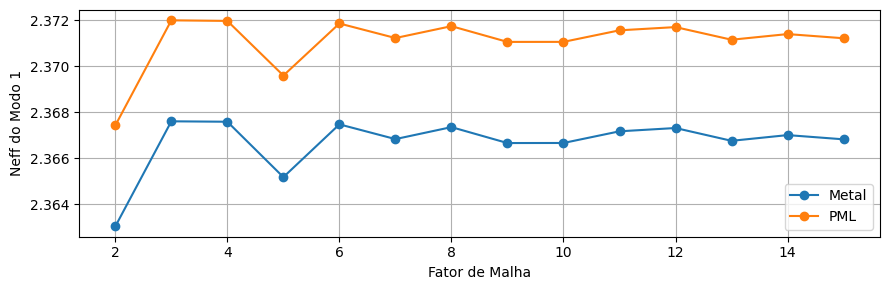

In [298]:

with h5py.File("convergencia_malha.h5", "r") as f:
    fator_m_malha = f["fator_m_malha"][:]
    neff_METAL = f["neff_modo1_METAL"][:]
    neff_PML = f["neff_modo1_PML"][:]

plot_curva_2d(2, [fator_m_malha, fator_m_malha], [neff_METAL, neff_PML], "Fator de Malha", "Neff do Modo 1", ["Metal", "PML"], "convergencia_FDE.png")

Foi considerado um fator de malha = 6

Condições de contorno PML

In [30]:
fator_m_malha = 6
bc = "PML"

m.switchtolayout()

m.select("mesh")
m.delete()
mesh(y_solver,bSolver,hSolver,fator_m_malha)

m.select("FDE")
m.delete()
solverFDE(y_solver,bSolver,hSolver,bc)

In [31]:
n_modes = int(m.findmodes())
print(f"modos encontrados: {n_modes}")

neff1 = np.real(m.getresult("FDE::data::mode1", "neff")[0][0])
neff2 = np.real(m.getresult("FDE::data::mode2", "neff")[0][0])
print(f"Neff modo 1 = {neff1}")
print(f"Neff modo 2 = {neff2}")

# obter perfil de campo Ey para cada modo

res1 = np.squeeze(m.getresult("FDE::data::mode1", "Ey"))
res2 = np.squeeze(m.getresult("FDE::data::mode2", "Ey"))

eixo_y = m.getresult("FDE::data::mode1", "y")/1e-6
eixo_z = m.getresult("FDE::data::mode1", "z")/1e-6


modos encontrados: 3
Neff modo 1 = 2.3718626992128784
Neff modo 2 = 2.339854717928589


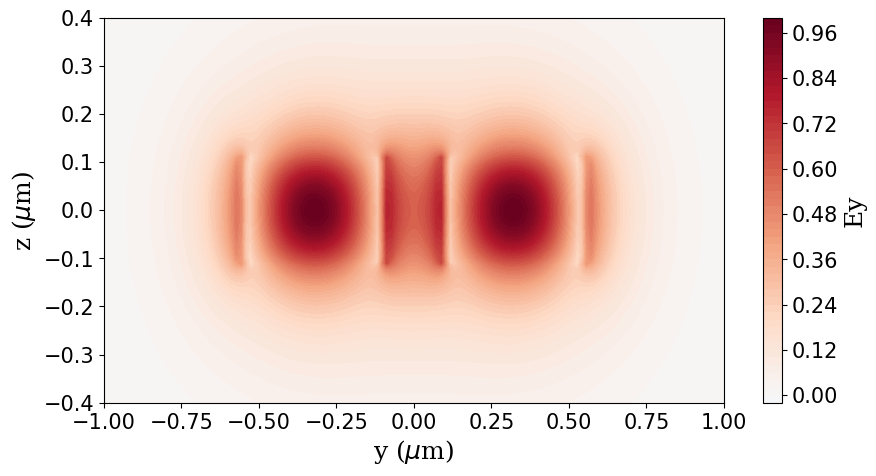

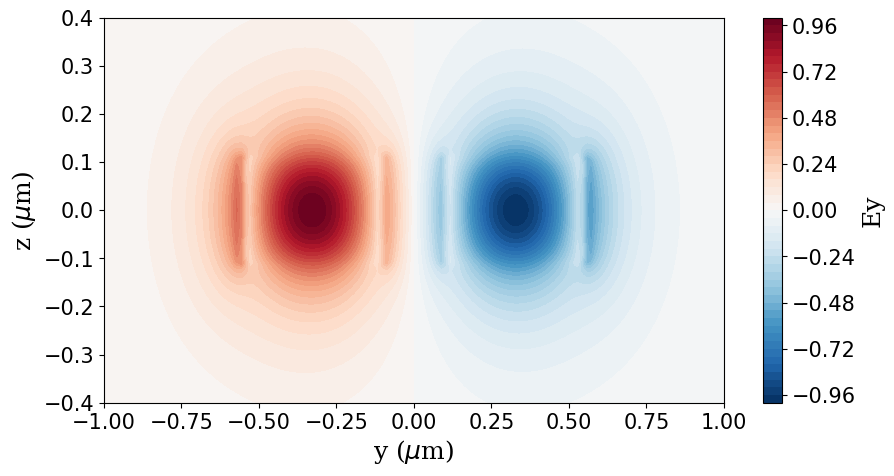

In [35]:
# Função para plotar os perfis de campo

def plotar_perfil_campo(eixo_y, eixo_z, resultado, xlim, ylim):
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111)
    Z, Y = np.meshgrid(eixo_z, eixo_y)
    contour = ax.contourf(Y, Z, np.real(resultado), 50, cmap="RdBu_r")
    # eixos
    ax.set_xlabel(r"y ($\mu$m)", fontsize=18, fontfamily='serif')
    ax.set_ylabel(r"z ($\mu$m)", fontsize=18, fontfamily='serif')
    ax.tick_params(axis='both', labelsize=15)           # valores dos eixos
    # barra de cor
    cbar = fig.colorbar(contour, ax=ax, label="Ey")
    cbar.ax.tick_params(labelsize=15)
    cbar.set_label("Ey", fontsize=18, fontfamily='serif')
    # limites
    contour.set_clim(xlim[0], xlim[1])
    plt.xlim(xlim[0], xlim[1])
    plt.ylim(ylim[0], ylim[1])
    plt.show()

xlim = (-1, 1)
ylim = (-0.4, 0.4)
plotar_perfil_campo(eixo_y, eixo_z, res1, xlim, ylim)
plotar_perfil_campo(eixo_y, eixo_z, res2, xlim, ylim)

### Determinando o comprimento de acoplamento

$L_x = \frac{\lambda}{2\Delta n}$

In [33]:
# Para este caso, temos:
lambda0 = 1.55e-6
deltan = abs(neff1 - neff2)
print(f"Delta n = {deltan}")
Lx = lambda0/(2*deltan)
print(f"Comprimento de acoplamento = {Lx*1e6:.2f} µm")

Delta n = 0.0320079812842895
Comprimento de acoplamento = 24.21 µm


In [34]:
def comprimento_acoplamento(Plambda0, Pneff1, Pneff2):
    deltan = abs(Pneff1 - Pneff2)
    Lx = Plambda0/(2*deltan)
    return Lx

In [36]:
def atualizar_solver_mesh(Pgap):
    bSolver = 2*largura_guia + Pgap
    m.switchtolayout()
    m.select("FDE")
    m.set("y span", 4*bSolver)
    m.select("mesh")
    m.set("y span", 2*bSolver)

def calcular_comprimento_acoplamento(Pgap):
    atualizar_acopladorDirecional_gap(m, Pgap)
    atualizar_solver_mesh(Pgap)

    n_modes = int(m.findmodes())
    print(f"modos encontrados: {n_modes}")

    temp_neff1 = np.real(m.getresult("FDE::data::mode1", "neff")[0][0])
    temp_neff2 = np.real(m.getresult("FDE::data::mode2", "neff")[0][0])

    l_acoplamento = comprimento_acoplamento(lambda0, temp_neff1, temp_neff2)
    print(f"Comprimento de acoplamento para gap = {Pgap*1e6:.2f} µm: {l_acoplamento*1e6:.2f} µm")
    return l_acoplamento

def plotar_comprimento_acoplamento_vs_gap(intervalo_gap, comprimentos_acoplamento):
    plt.figure()
    plt.plot(intervalo_gap*1e6, comprimentos_acoplamento*1e6, marker='o')
    plt.xlabel(r"Gap ($\mu$m)")
    plt.ylabel(r"Comprimento de Acoplamento ($\mu$m)")
    plt.title("Comprimento de Acoplamento vs Gap")
    plt.grid()
    plt.show()

In [38]:
# Análise para bc = Metal

lambda0 = 1.55e-6
fator_m_malha = 6
bc = "Metal"
resetar_layout(m)
criar_acopladorDirecional(m, material_dispositivo, curvatura, altura_guia, largura_guia, gap, Lc, comprimento_guias_portas)
solverFDE(y_solver,bSolver,hSolver,bc)
mesh(y_solver,bSolver,hSolver,fator_m_malha)

intervalo_gap = np.arange(0, 0.5e-6, 0.05e-6)
comprimentos_acoplamento = np.zeros(len(intervalo_gap))

for i, gap in enumerate(intervalo_gap):
    print(f"Calculando para gap = {gap*1e6:.2f}")
    aux = calcular_comprimento_acoplamento(gap)
    comprimentos_acoplamento[i] = aux



Calculando para gap = 0.00
modos encontrados: 20
Comprimento de acoplamento para gap = 0.00 µm: 1.90 µm
Calculando para gap = 0.05
modos encontrados: 20
Comprimento de acoplamento para gap = 0.05 µm: 5.58 µm
Calculando para gap = 0.10
modos encontrados: 20
Comprimento de acoplamento para gap = 0.10 µm: 10.01 µm
Calculando para gap = 0.15
modos encontrados: 20
Comprimento de acoplamento para gap = 0.15 µm: 16.17 µm
Calculando para gap = 0.20
modos encontrados: 20
Comprimento de acoplamento para gap = 0.20 µm: 24.89 µm
Calculando para gap = 0.25
modos encontrados: 20
Comprimento de acoplamento para gap = 0.25 µm: 38.42 µm
Calculando para gap = 0.30
modos encontrados: 20
Comprimento de acoplamento para gap = 0.30 µm: 58.93 µm
Calculando para gap = 0.35
modos encontrados: 20
Comprimento de acoplamento para gap = 0.35 µm: 89.32 µm
Calculando para gap = 0.40
modos encontrados: 20
Comprimento de acoplamento para gap = 0.40 µm: 136.20 µm
Calculando para gap = 0.45
modos encontrados: 20
Comprim

In [39]:
# Análise para bc = PML

lambda0 = 1.55e-6
fator_m_malha = 6
bc = "PML"
resetar_layout(m)
criar_acopladorDirecional(m, material_dispositivo, curvatura, altura_guia, largura_guia, gap, Lc, comprimento_guias_portas)
solverFDE(y_solver,bSolver,hSolver,bc)
mesh(y_solver,bSolver,hSolver,fator_m_malha)
intervalo_gap = np.arange(0, 0.5e-6, 0.05e-6)
comprimentos_acoplamento_PML = np.zeros(len(intervalo_gap))

for i, gap in enumerate(intervalo_gap):
    print(f"Calculando para gap = {gap*1e6:.2f}")
    aux = calcular_comprimento_acoplamento(gap)
    comprimentos_acoplamento_PML[i] = aux

Calculando para gap = 0.00
modos encontrados: 3
Comprimento de acoplamento para gap = 0.00 µm: 1.91 µm
Calculando para gap = 0.05
modos encontrados: 3
Comprimento de acoplamento para gap = 0.05 µm: 5.57 µm
Calculando para gap = 0.10
modos encontrados: 3
Comprimento de acoplamento para gap = 0.10 µm: 9.90 µm
Calculando para gap = 0.15
modos encontrados: 3
Comprimento de acoplamento para gap = 0.15 µm: 15.86 µm
Calculando para gap = 0.20
modos encontrados: 3
Comprimento de acoplamento para gap = 0.20 µm: 24.21 µm
Calculando para gap = 0.25
modos encontrados: 2
Comprimento de acoplamento para gap = 0.25 µm: 37.01 µm
Calculando para gap = 0.30
modos encontrados: 2
Comprimento de acoplamento para gap = 0.30 µm: 56.16 µm
Calculando para gap = 0.35
modos encontrados: 2
Comprimento de acoplamento para gap = 0.35 µm: 84.17 µm
Calculando para gap = 0.40
modos encontrados: 2
Comprimento de acoplamento para gap = 0.40 µm: 126.71 µm
Calculando para gap = 0.45
modos encontrados: 2
Comprimento de aco

In [40]:
# Salvar os resultados

with h5py.File("comprimento_acoplamento_vs_gap.h5", "w-") as f:
    f.create_dataset("intervalo_gap", data=intervalo_gap)
    f.create_dataset("comprimentos_acoplamento", data=comprimentos_acoplamento)
    f.create_dataset("comprimentos_acoplamento_PML", data=comprimentos_acoplamento_PML)

In [41]:
# Extrair os resultados para plotar a curva

with h5py.File("comprimento_acoplamento_vs_gap.h5", "r") as f:
    intervalo_gap = f["intervalo_gap"][:]
    comprimentos_Metal = f["comprimentos_acoplamento"][:]
    comprimentos_PML = f["comprimentos_acoplamento_PML"][:]

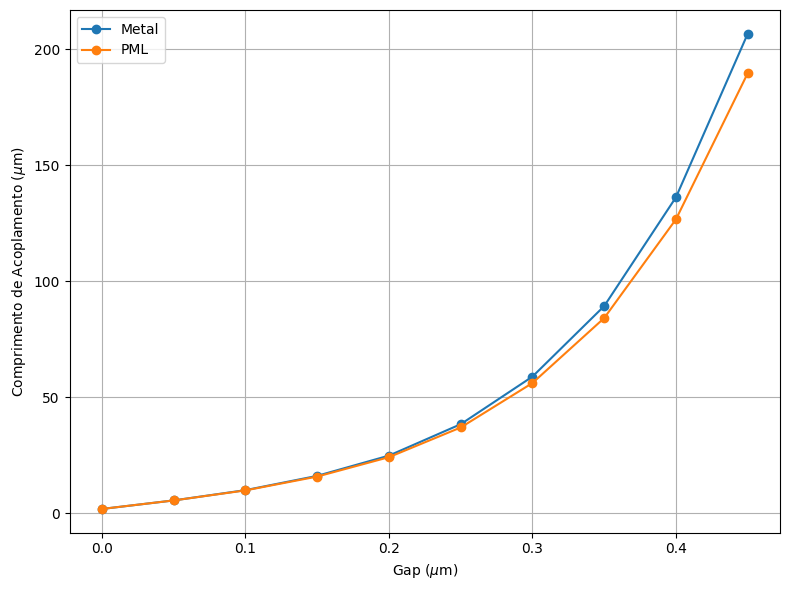

In [44]:
plot_curva_2d(2, [intervalo_gap*1e6, intervalo_gap*1e6], [comprimentos_Metal*1e6, comprimentos_PML*1e6], "Gap ($\\mu$m)", "Comprimento de Acoplamento ($\\mu$m)", ["Metal", "PML"])

### Cálculo do coeficiente de acoplamento

Primeiro foi ilustrado o coeficiente de acoplamento em função do gap.

Considerando um gap de 200 nm, foram utilizada as equações abaixo para determinar k, t e C.

$t^2 = \cos ^ 2 (CL)$

$ \kappa ^ 2 = \sin ^ 2 (CL) $

modos encontrados: 3

Neff modo 1 = 2.3718626992128784

Neff modo 2 = 2.339854717928589

In [45]:
lambda0 = 1.55e-6

def coefAcoplamento(Plambda0, Pneff1, Pneff2):
    deltan = abs(Pneff1 - Pneff2)
    coef = pi*deltan/Plambda0
    return coef

In [46]:
# gap = 200 nm
n1 = 2.3718626992128784
n2 = 2.339854717928589

C = coefAcoplamento(lambda0, n1, n2)

Lc_VAR = np.arange(1e-6, 100e-6, 1e-6)
Lc_VAR = np.linspace(1e-6, 25e-6, 500) # Alternativa para criar o array de Lc_VAR

k_2 = np.sin(C*Lc_VAR)**2
t_2 = np.cos(C*Lc_VAR)**2


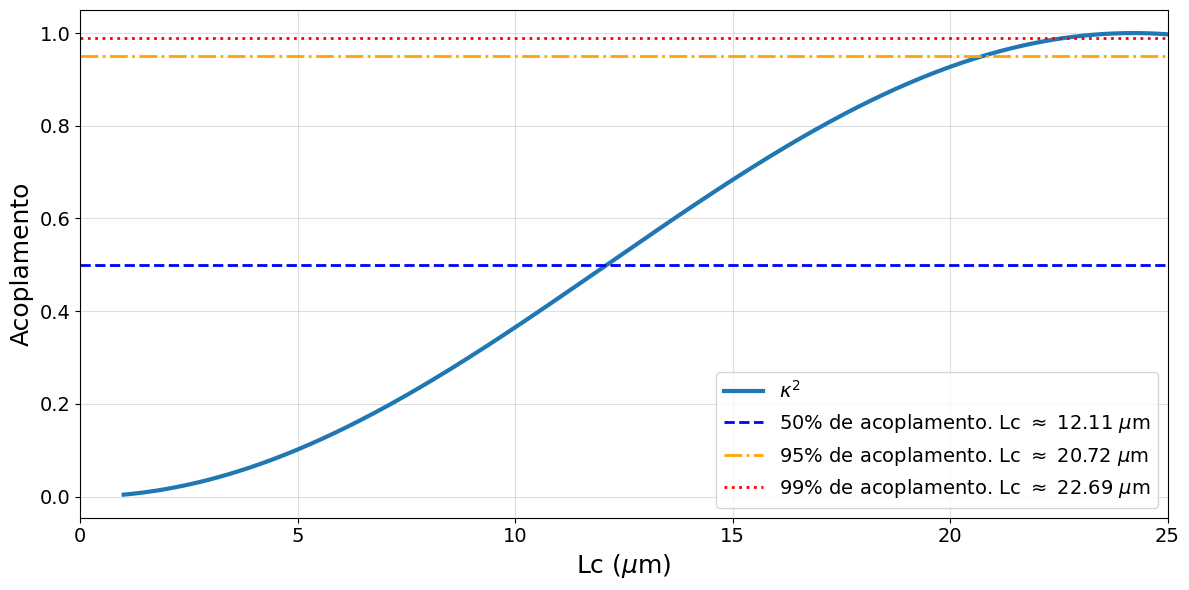

In [71]:
plt.figure(figsize=(12, 6))

idx_50 = np.argmin(np.abs(k_2 - 0.5))
idx_95 = np.argmin(np.abs(k_2 - 0.95))
idx_99 = np.argmin(np.abs(k_2 - 0.99))

plt.plot(Lc_VAR*1e6, k_2, label="$\\kappa^2$", linewidth=3)
# plt.plot(Lc_VAR*1e6, t_2, label="$t^2$", linewidth=3)

plt.xlabel("Lc ($\\mu$m)", fontsize=18)
plt.ylabel("Acoplamento", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.axhline(y=0.5, color='b', linestyle='--', linewidth=2,
            label=f"50% de acoplamento. Lc $\\approx$ {Lc_VAR[idx_50]*1e6:.2f} $\\mu$m")
plt.axhline(y=0.95, color='orange', linestyle='-.', linewidth=2,
            label=f"95% de acoplamento. Lc $\\approx$ {Lc_VAR[idx_95]*1e6:.2f} $\\mu$m")
plt.axhline(y=0.99, color='r', linestyle=':', linewidth=2,
            label=f"99% de acoplamento. Lc $\\approx$ {Lc_VAR[idx_99]*1e6:.2f} $\\mu$m")

plt.grid(alpha=0.4)
plt.xlim(0, 25)

plt.legend(loc='lower right',fontsize=14,frameon=True)

plt.tight_layout()
plt.show()

In [72]:
m.close()

## III - Solução dos modos por FDTD resultando em uma matriz de parâmetros S para o dispositivo

In [342]:
f = lumapi.FDTD(hide=False) 

In [281]:
# Valores oriundos da simulação FDE:

Lc = 12.11e-6 # fde - Comprimento para 50/50 de acoplamento       (variável)

In [343]:
time = (np.pi*curvatura + Lc)*7/c + 200e-15

# Variáveis FDTD: --------------------------------------------------------------
comprimento_guias_portas = 2e-6 

Lc = 9.55e-6


# Medidas do solver:
ganho_dist_ymin_bc = 2e-6
bSolver = 2*curvatura + Lc
hSolver = curvatura + 2*largura_guia + gap
y_solver = largura_guia + gap/2 + curvatura/2 - ganho_dist_ymin_bc/2

zSpan_solver = 4e-6
ySpan_solver = hSolver + ganho_dist_ymin_bc
xSpan_solver = bSolver + comprimento_guias_portas
bc_z = "Symmetric" # Symmetric (modo TE), Anti-symmetric (modo TM)
modo = "fundamental TE mode"
mesh_accuracy = 4


# Variáveis para construção das portas:
injection_axis = 'y-axis'
xb = bSolver/2
x_port = [xb, -xb, xb, -xb]
y_port = [-(gap + largura_guia)/2, -(gap + largura_guia)/2, (curvatura), (curvatura)]


lambda_i = 1500e-9
lambda_f = 1600e-9
qtd_pontos = 21
intervalo_lambda = np.linspace(lambda_i, lambda_f, qtd_pontos)

def indice_lambda(valor, vetor=intervalo_lambda):
    return np.argmin(np.abs(vetor - valor))
print(f"O índice para filtrar λ = 1.55 µm é: {indice_lambda(1.55e-6)}")       # índice para λ = 1.55 µm

i_1550 = indice_lambda(1.55e-6)

O índice para filtrar λ = 1.55 µm é: 10


In [344]:
def solverFDTD(solver):
    solver.addfdtd()
    solver.set("x",0)
    solver.set("y",y_solver)
    solver.set("z",0)
    solver.set("x span", xSpan_solver)
    solver.set("y span", ySpan_solver)
    solver.set("z span", zSpan_solver)
    solver.set("simulation time", time)
    solver.set("background material", "SiO2 (Glass) - Palik")
    solver.set("z min bc", bc_z)
    solver.set("mesh accuracy", mesh_accuracy)

def updateSolverFDTD(solver):
    solver.select("FDTD")
    solver.set("x",0)
    solver.set("y",y_solver)
    solver.set("z",0)
    solver.set("x span", xSpan_solver)
    solver.set("y span", ySpan_solver)
    solver.set("z span", zSpan_solver)
    solver.set("z min bc", bc_z)
    solver.set("simulation time", time)
    solver.set("mesh accuracy", mesh_accuracy)

def monitorVideo(solver):
    solver.addmovie()
    solver.set("name", "video")
    solver.set("x",0)
    solver.set("y",y_solver)
    solver.set("z",0)
    solver.set("x span", xSpan_solver)
    solver.set("y span", ySpan_solver)

def configurar_portas(solver, modo):
    for i in range(4):
        solver.addport()
        solver.set("name", f"port{i+1}")
        solver.set("injection axis", injection_axis)
        solver.set("x", x_port[i])
        solver.set("y", y_port[i])
        solver.set("z", 0)
        solver.set("z span", comprimento_guias_portas)
        # solver.set("mode selection", "fundamental TE mode")
        solver.set("direction", "Backward")
        solver.set("mode selection", "fundamental mode")


    solver.setnamed("FDTD::ports::port2", "direction", "Forward")
    solver.setnamed("FDTD::ports::port1", "mode selection", modo)
    solver.setnamed("FDTD::ports::port1", "injection axis", "x-axis")
    solver.setnamed("FDTD::ports::port2", "injection axis", "x-axis")
    solver.setnamed("FDTD::ports::port1", "y span", 2*comprimento_guias_portas)
    solver.setnamed("FDTD::ports::port2", "y span", 2*comprimento_guias_portas)
    solver.setnamed("FDTD::ports::port3", "x span", comprimento_guias_portas)
    solver.setnamed("FDTD::ports::port4", "x span", comprimento_guias_portas)
    
    solver.setnamed("FDTD", "global source wavelength start", lambda_i)
    solver.setnamed("FDTD", "global source wavelength stop", lambda_f)
    solver.setnamed("FDTD::ports", "monitor frequency points", 21)

def add_monitor_xy(solver):
    solver.addprofile()
    solver.set("name", "monitor")
    solver.set("override global monitor settings", True)
    solver.set("frequency points", 21)
    solver.set("x",0)
    solver.set("y",y_solver)
    solver.set("z",0)
    solver.set("x span", xSpan_solver + 1e-6)
    solver.set("y span", ySpan_solver + 1e-6)

def add_monitor_xz(solver):
    solver.addprofile()
    solver.set("name", "monitor2")
    solver.set("override global monitor settings", True)
    solver.set("frequency points", 21)
    solver.set("monitor type", "2D Y-normal")
    solver.set("x",0)
    solver.set("y",curvatura + comprimento_guias_portas/2)
    solver.set("z",0)
    solver.set("x span", xSpan_solver + 1e-6)
    solver.set("z span", zSpan_solver + 1e-6)

def checar_tamanho_simulacao(solver):
    info = solver.runsystemcheck()
    print(f"{((info['Approximate_Memory_Requirements']['Running_Simulation_Bytes']/(1024))*1e-3):.0f} MB")

In [345]:
def extrair_perfil_campo_E(solver):
    e_field = (np.abs(np.squeeze(solver.getelectric("monitor")))**2)
    x_efield = solver.getdata("monitor", "x")
    y_efield = solver.getdata("monitor", "y")
    e_field = e_field[:, :, 1]
    return x_efield, y_efield, e_field

def extrair_parametro_T(solver):
    dados_portas = []
    for i in range(4):
        dados_portas.append(solver.getresult(f"FDTD::ports::port{i+1}", "T"))
    return dados_portas

In [346]:
resetar_layout(f)

In [347]:
criar_acopladorDirecional(f, material_dispositivo, curvatura, altura_guia, largura_guia, gap, Lc, comprimento_guias_portas)

solverFDTD(f)

reset_view(f)

configurar_portas(f, modo)

add_monitor_xy(f)

In [322]:
checar_tamanho_simulacao(f)

3514 MB


In [275]:
f.save("acopladorDirecionalTESTE.fsp")

In [323]:
f.run()

In [277]:
f_x, f_y, field_E = extrair_perfil_campo_E(f)
T_portas = extrair_parametro_T(f)

In [278]:
filename = "simulacoes_acoplador_dados_50_fde_otim.h5"
with h5py.File(filename, 'w') as hf:
    grupo = hf.create_group("simulacoes_50_fde_FDTD")
    fieldE = grupo.create_group("field")
    fieldE.create_dataset("field_E", data=field_E)
    fieldE.create_dataset("x", data=f_x)
    fieldE.create_dataset("y", data=f_y)
    portas_grp = grupo.create_group("portas")
    for idx, dados in enumerate(T_portas, start=1):
        pgrp = portas_grp.create_group(f"porta{idx}")
        pgrp.create_dataset("lambda", data=dados["lambda"])
        pgrp.create_dataset("T", data=dados["T"])
    

In [279]:
with h5py.File(filename, "r") as hf:
        grp = hf["simulacoes_50_fde_FDTD"]
        x = grp["field"]["x"][:]
        y = grp["field"]["y"][:]
        e_field = grp["field"]["field_E"][:]


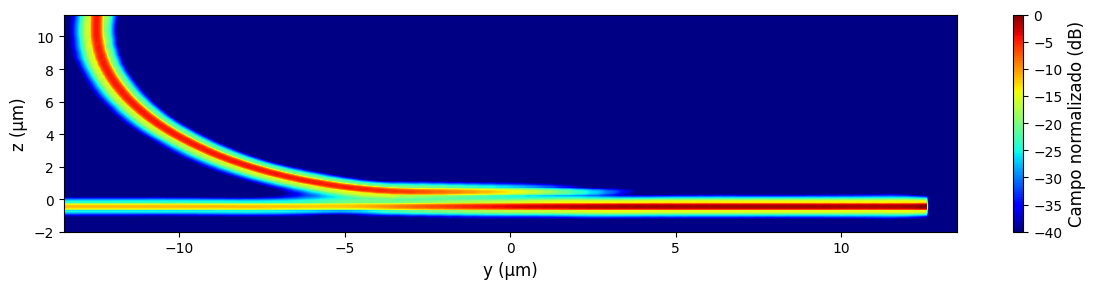

In [280]:
def plotar_perfil_campo_dB(eixo_y, eixo_z, campo,
                           vmin=-40, vmax=0,
                           cmap="jet"):

    fig = plt.figure(figsize=(12,3))
    ax = fig.add_subplot(111)

    # criar grade
    Z, Y = np.meshgrid(eixo_z*1e6, eixo_y*1e6)

    # módulo do campo
    campo_abs = np.abs(campo)

    # normalizar
    campo_abs = campo_abs / np.max(campo_abs)

    # converter para dB
    campo_db = 10*np.log10(campo_abs)

    # limitar valores abaixo de vmin
    campo_db = np.clip(campo_db, vmin, vmax)

    # níveis do contour (controla a barra)
    levels = np.linspace(vmin, vmax, 100)

    contour = ax.contourf(Y, Z, campo_db,
                          levels=levels,
                          cmap=cmap)

    ax.set_xlabel("y (µm)", fontsize=12)
    ax.set_ylabel("z (µm)", fontsize=12)

    # colorbar
    cbar = fig.colorbar(contour, ax=ax)
    
    ticks = np.arange(vmin, vmax+1, 5)
    cbar.set_ticks(ticks)
    cbar.set_label("Campo normalizado (dB)", fontsize=12)

    plt.tight_layout()
    plt.show()

plotar_perfil_campo_dB(x,y,e_field)

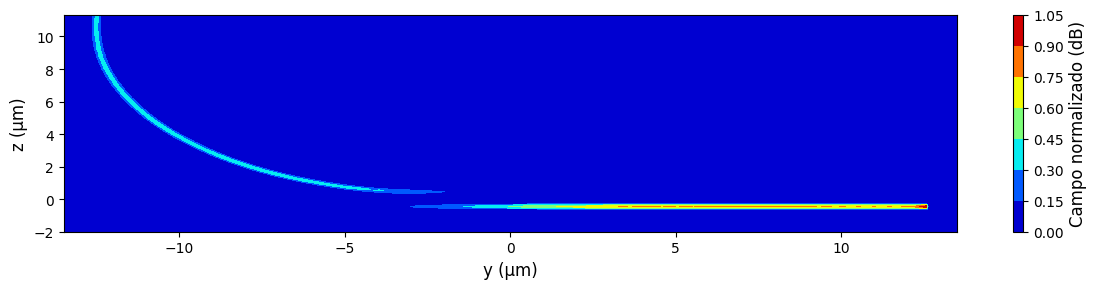

In [304]:
def plotar_perfil_campo(eixo_y, eixo_z, campo,
                           vmin=-40, vmax=0,
                           cmap="jet"):

    fig = plt.figure(figsize=(12,3))
    ax = fig.add_subplot(111)

    # criar grade
    Z, Y = np.meshgrid(eixo_z*1e6, eixo_y*1e6)

    # módulo do campo
    campo_abs = np.abs(campo)

    # normalizar
    campo_abs = campo_abs / np.max(campo_abs)

    # níveis do contour (controla a barra)
    #levels = np.linspace(vmin, vmax, 100)

    contour = ax.contourf(Y, Z, campo_abs,
                          cmap=cmap)

    ax.set_xlabel("y (µm)", fontsize=12)
    ax.set_ylabel("z (µm)", fontsize=12)

    # colorbar
    cbar = fig.colorbar(contour, ax=ax)
    
    cbar.set_label("Campo normalizado (dB)", fontsize=12)

    plt.tight_layout()
    plt.show()

plotar_perfil_campo(x,y,e_field)

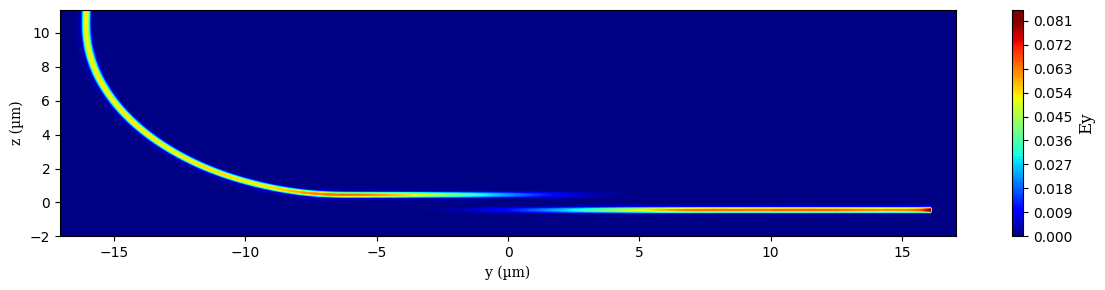

In [253]:
def plotar_perfil_campo(eixo_y, eixo_z, resultado, nome_arquivo):
    fig = plt.figure(figsize=(12, 3))
    ax = fig.add_subplot(111)
    Z, Y = np.meshgrid(eixo_z*1e6, eixo_y*1e6)
    contour = ax.contourf(Y, Z, np.real(resultado), 100, cmap="jet", vmin=0, vmax=0.081)
    # eixos
    ax.set_xlabel("y (µm)", fontsize=10, fontfamily='serif')
    ax.set_ylabel("z (µm)", fontsize=10, fontfamily='serif')
    ax.tick_params(axis='both', labelsize=10)           # valores dos eixos
    # barra de cor
    cbar = fig.colorbar(contour, ax=ax, label="Ey")
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Ey", fontsize=12, fontfamily='serif')
    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=300)
    plt.show()
plotar_perfil_campo(x,y,e_field, "perfil_campo1.png")


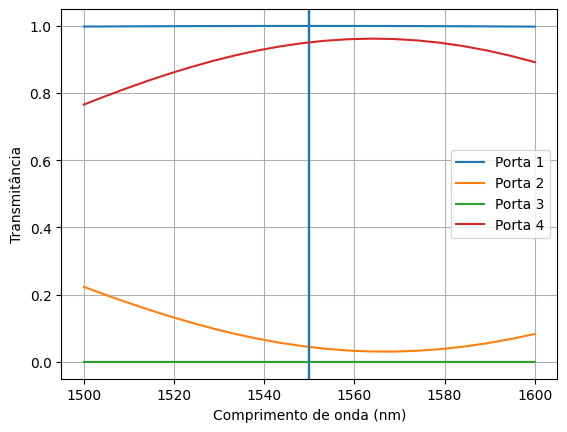

In [183]:
with h5py.File(filename, "r") as hf:
    grp = hf["simulacoes_50_fde_FDTD"]
    portas = grp["portas"]
    
    for i in range(1, 5):
        pgrp = portas[f"porta{i}"]
        lmbd = pgrp["lambda"][:]
        T = pgrp["T"][:]
        plt.axvline(1550)
        plt.plot(lmbd*1e9, abs(T), label=f'Porta {i}')

plt.xlabel('Comprimento de onda (nm)')
plt.ylabel('Transmitância')
plt.legend()
plt.grid(True)
plt.show()

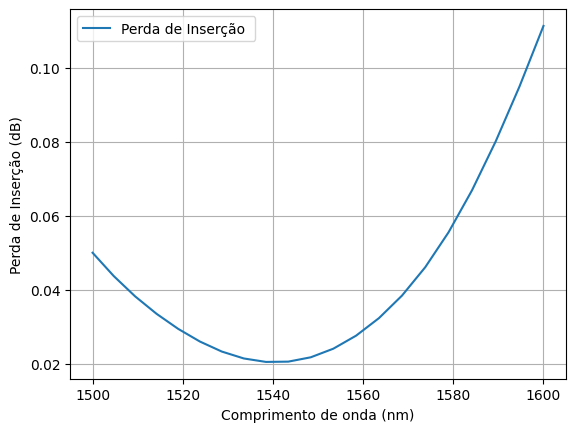

In [184]:
# Perda de inserção:
with h5py.File(filename, "r") as hf:
    grp = hf["simulacoes_50_fde_FDTD"]
    portas = grp["portas"]

    lmbd = portas["porta4"]["lambda"][:]
    T_porta4 = portas["porta4"]["T"][:]
    T_porta2 = portas["porta2"]["T"][:]
    perda_insercao = -10 * np.log10(abs(T_porta4) + abs(T_porta2))

plt.plot(lmbd*1e9, perda_insercao, label='Perda de Inserção ')
plt.xlabel('Comprimento de onda (nm)')
plt.ylabel('Perda de Inserção (dB)')
plt.legend()
plt.grid(True)
plt.show()

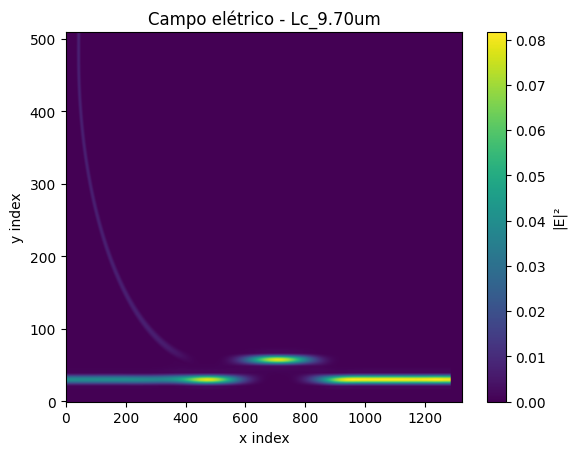

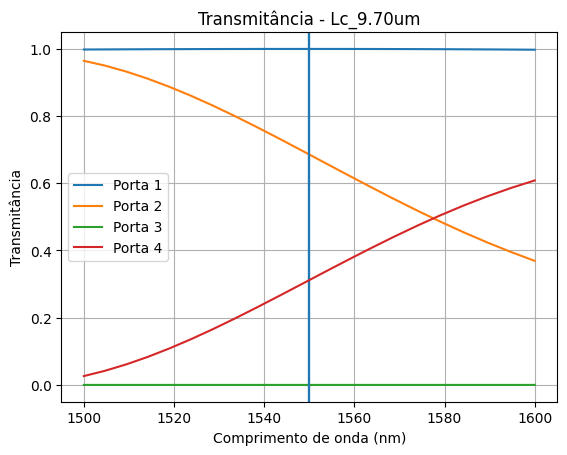

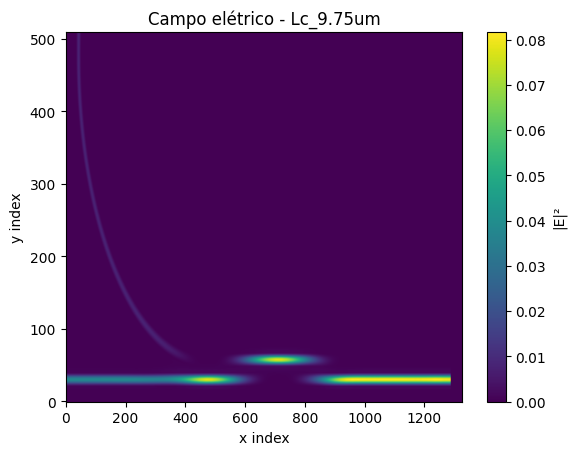

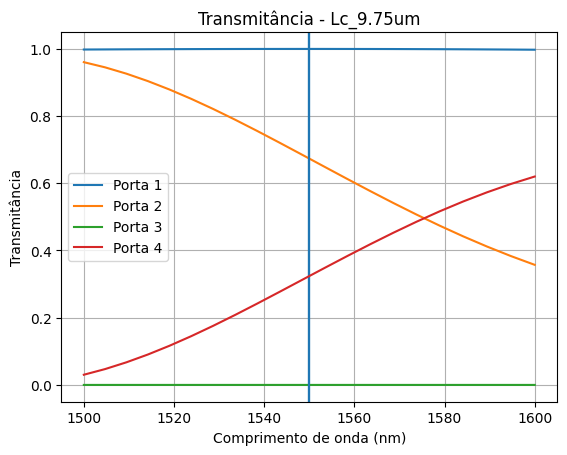

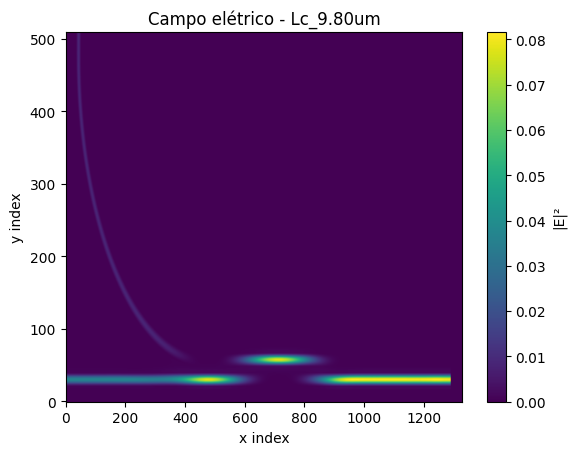

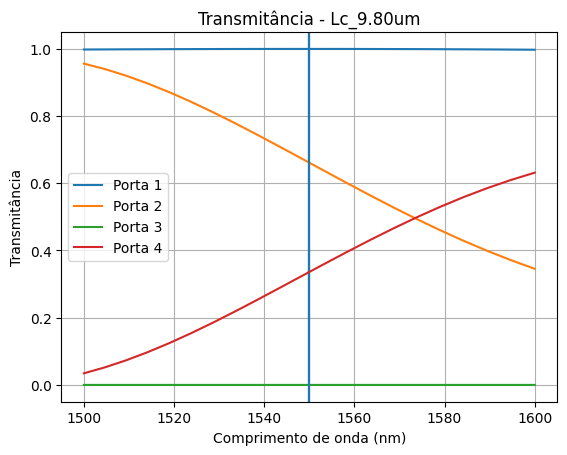

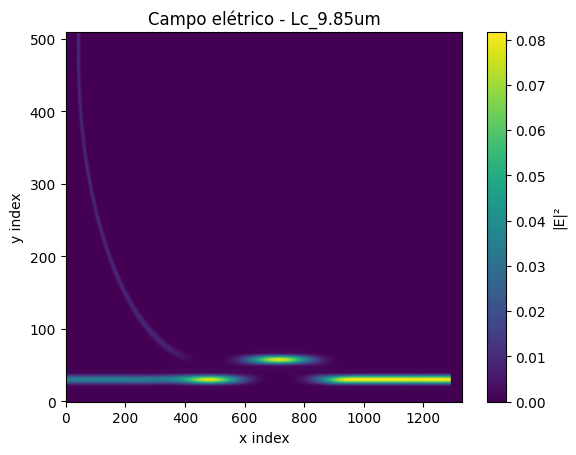

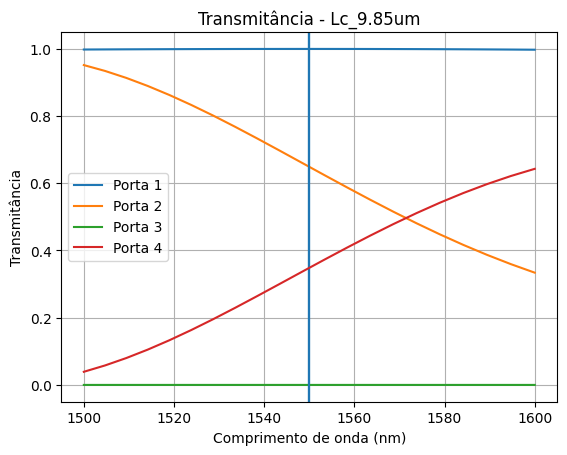

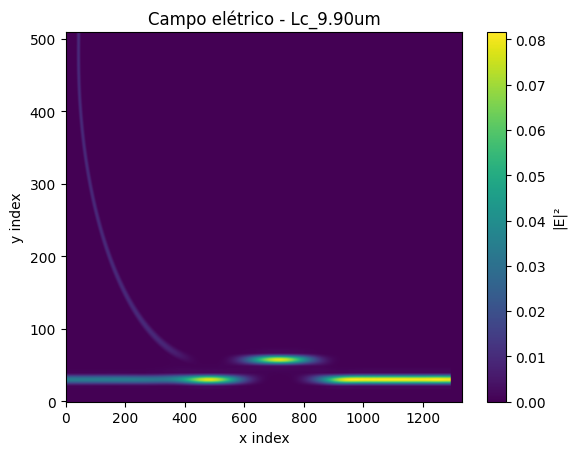

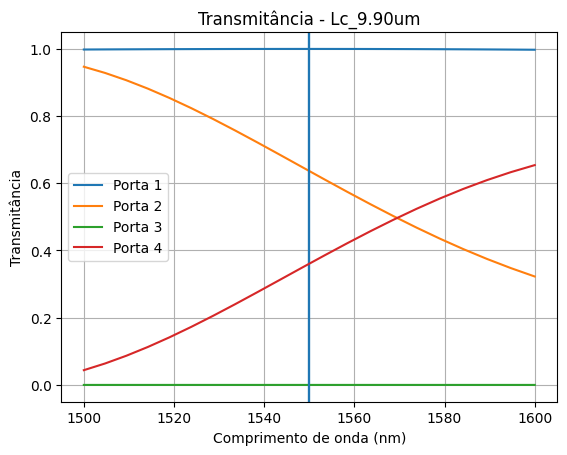

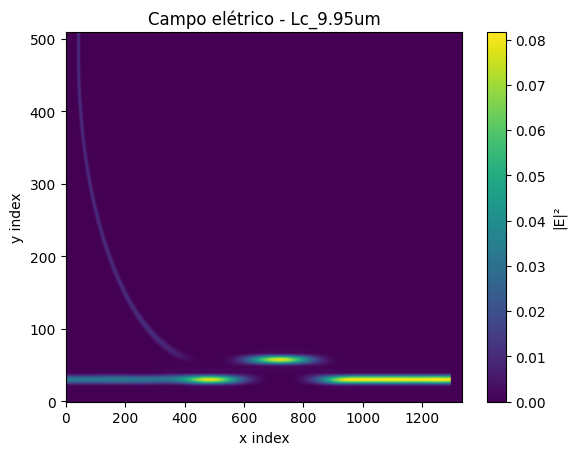

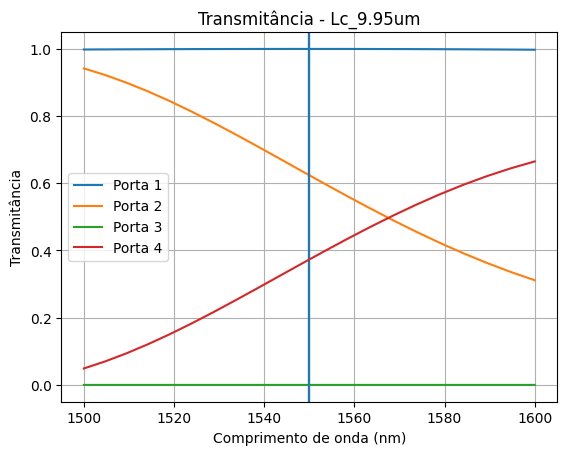

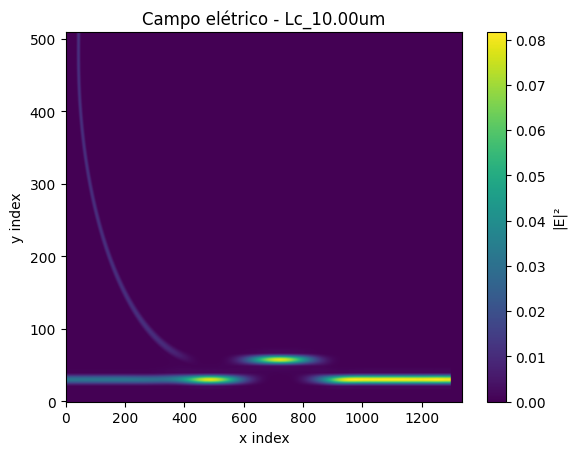

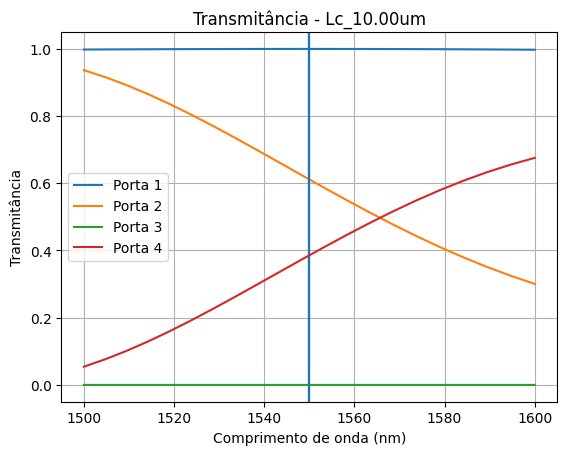

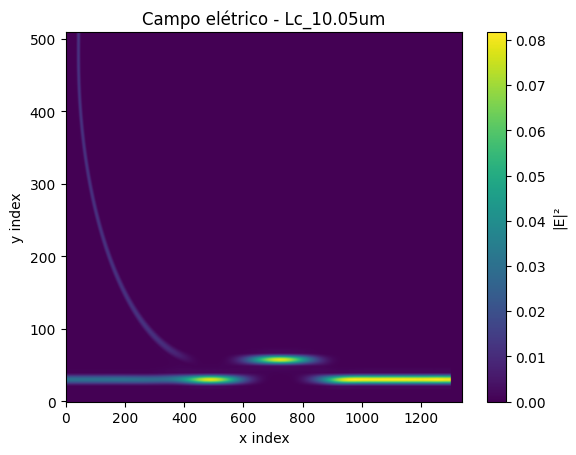

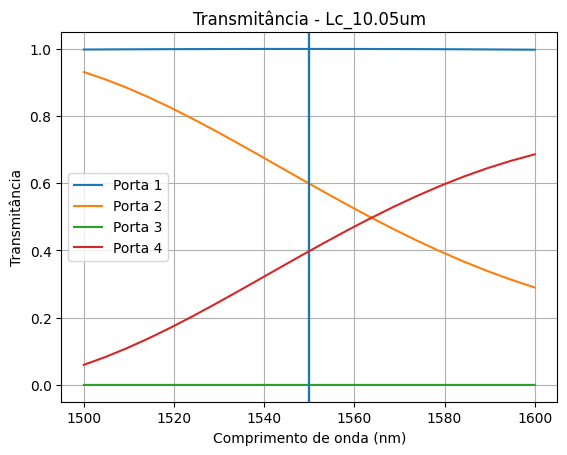

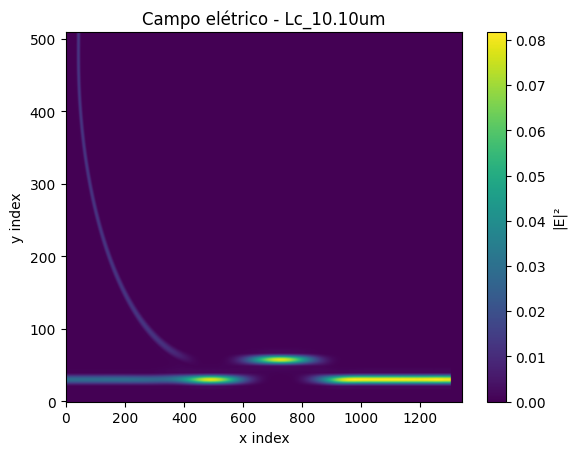

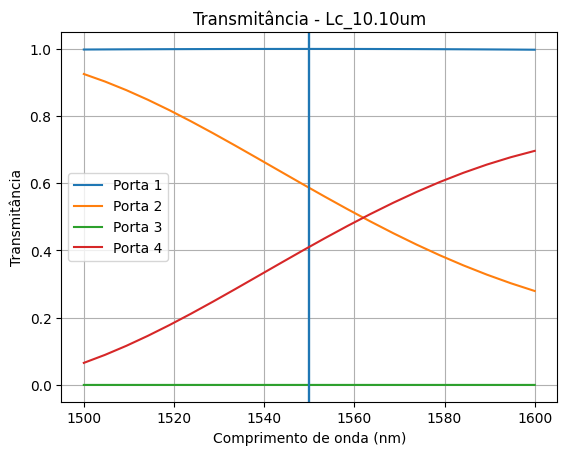

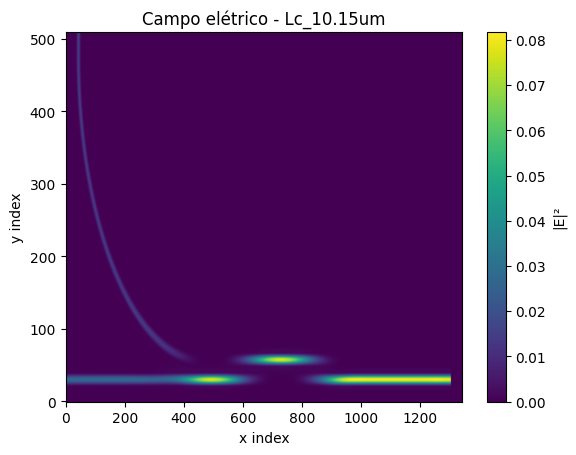

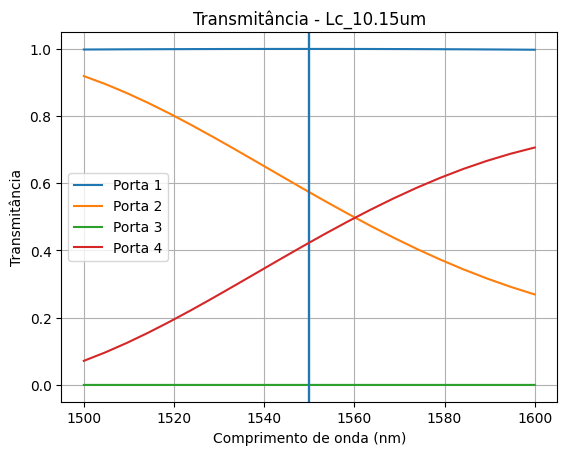

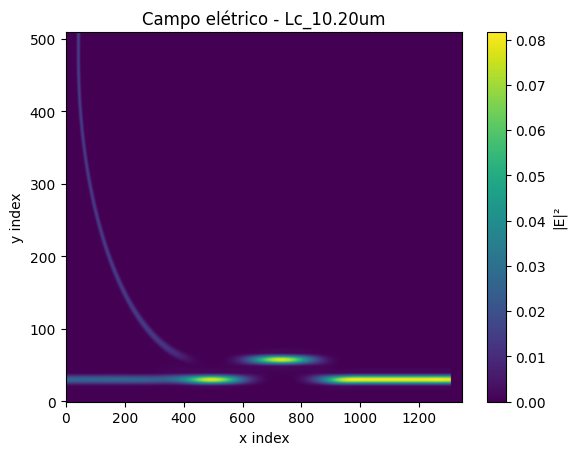

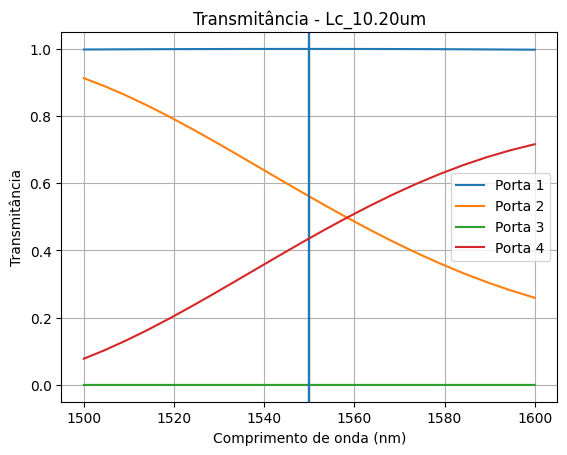

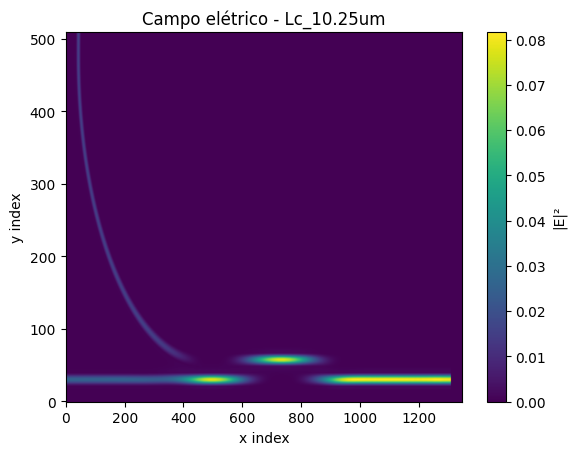

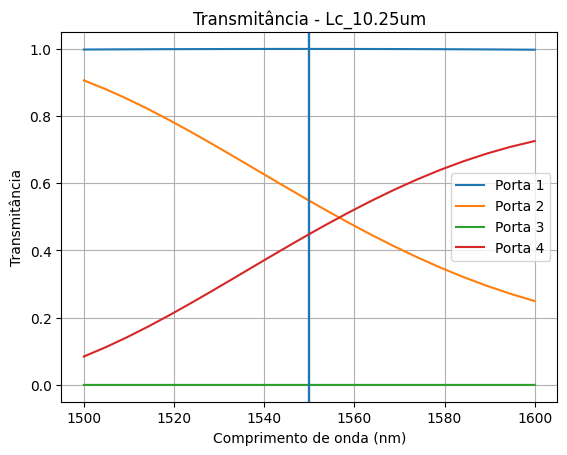

In [260]:

Lc = np.linspace(9.7e-6, 10.25e-6, 12) # arquivo = "resultados_mesh_4_refinadoTMAmpliado.h5"


arquivo = "resultados_mesh_4_refinadoTMAmpliado.h5"
for j in Lc:
    Lc_escolhido = f"Lc_{j*1e6:.2f}um"
    with h5py.File(arquivo, "r") as hf:
        grp = hf[Lc_escolhido]
        e_field = grp["e_field"][:]

    plt.figure()
    plt.imshow(e_field.T, origin='lower', aspect='auto')
    plt.colorbar(label='|E|²')
    plt.xlabel('x index')
    plt.ylabel('y index')
    plt.title(f'Campo elétrico - {Lc_escolhido}')
    plt.show()
    plt.figure()

    with h5py.File(arquivo, "r") as hf:
        grp = hf[Lc_escolhido]
        portas = grp["portas"]
        
        for i in range(1, 5):
            pgrp = portas[f"porta{i}"]
            lmbd = pgrp["lambda"][:]
            T = pgrp["T"][:]
            plt.axvline(1550)
            plt.plot(lmbd*1e9, abs(T), label=f'Porta {i}')

    plt.xlabel('Comprimento de onda (nm)')
    plt.ylabel('Transmitância')
    plt.title(f'Transmitância - {Lc_escolhido}')
    plt.legend()
    plt.grid(True)
    plt.show()


Processando: otim_TEpt1_mesh3.h5


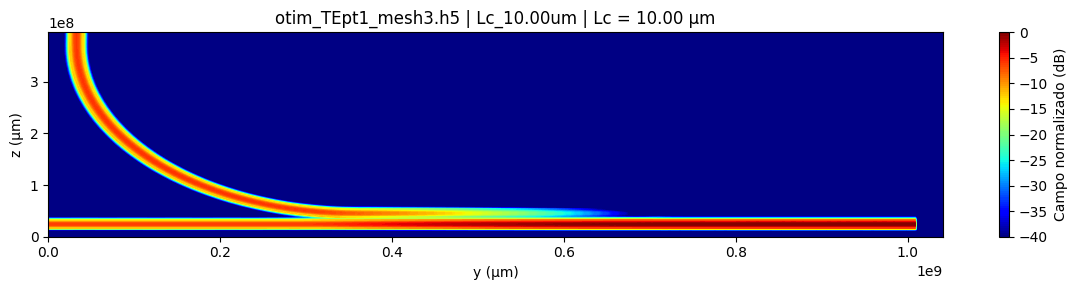

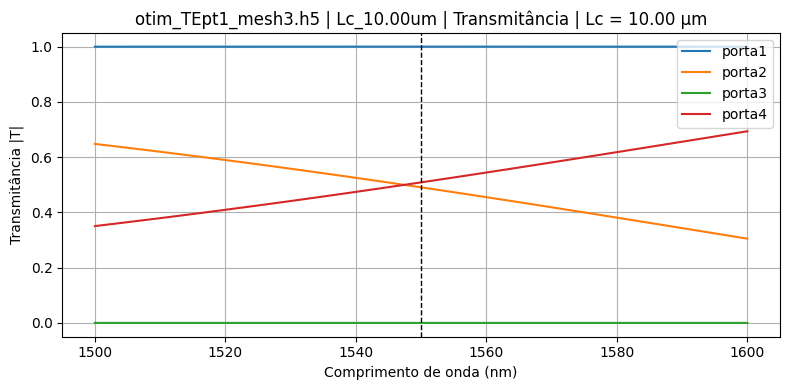

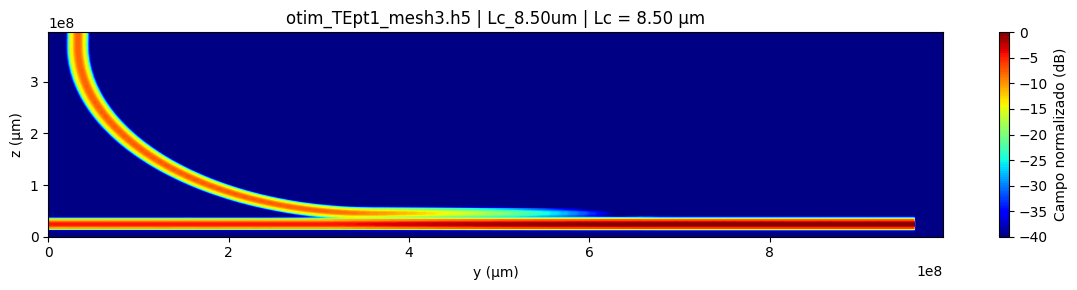

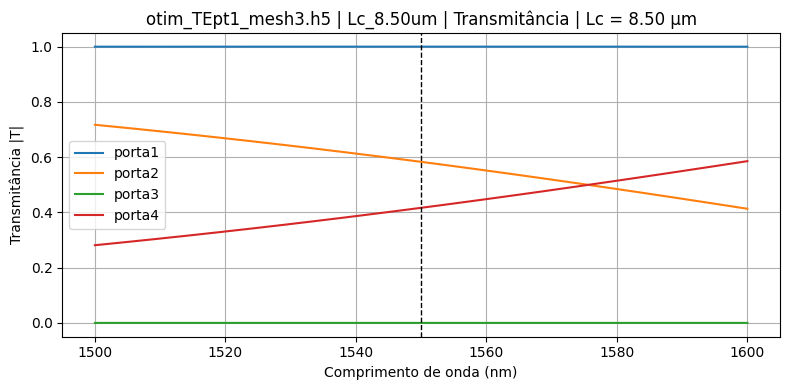

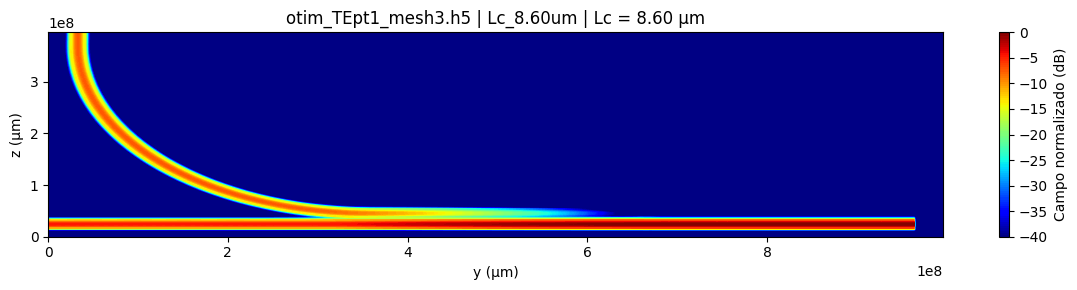

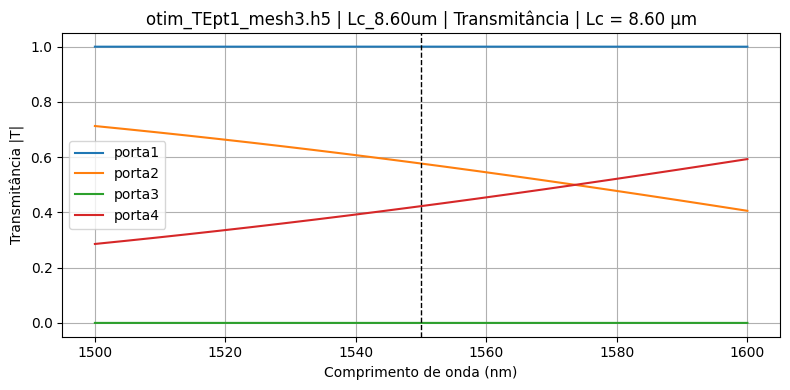

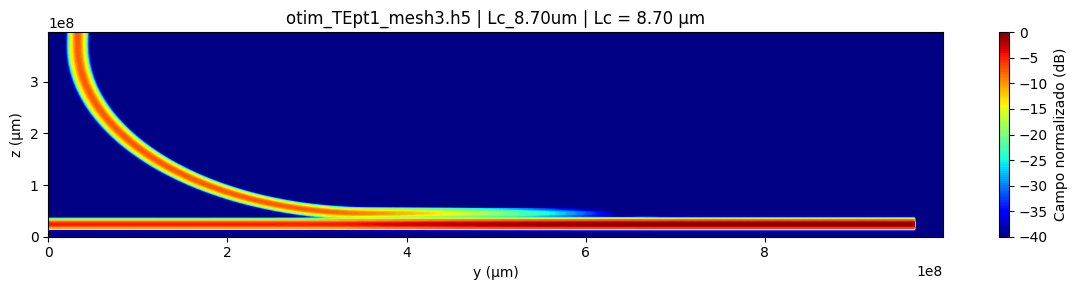

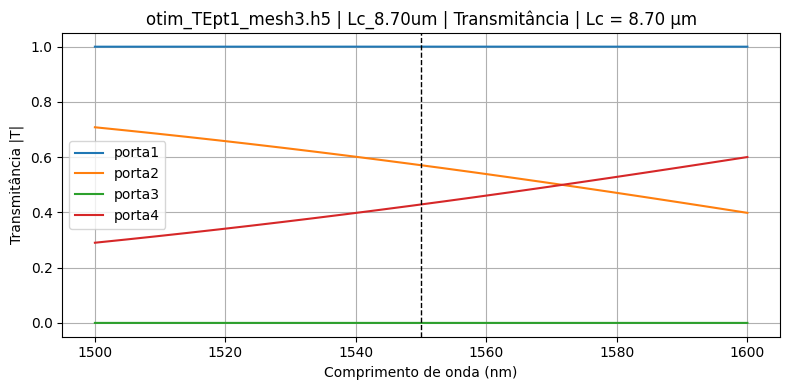

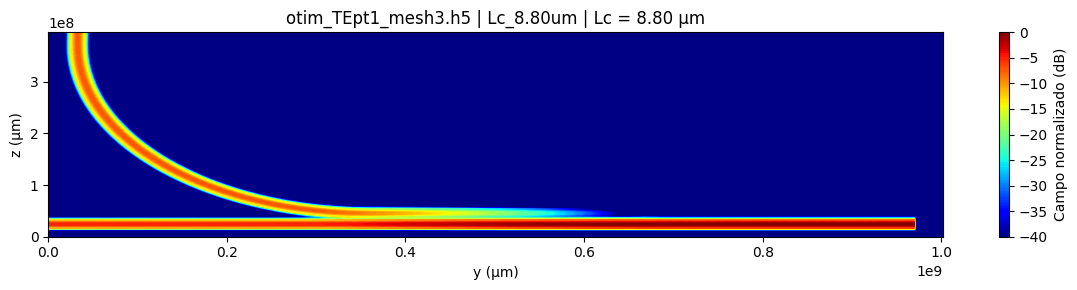

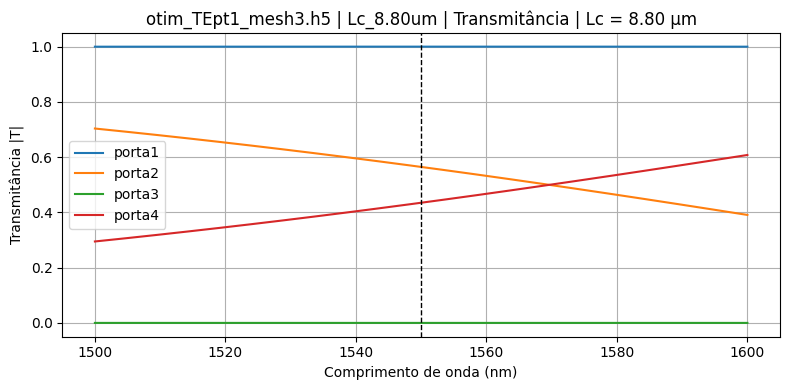

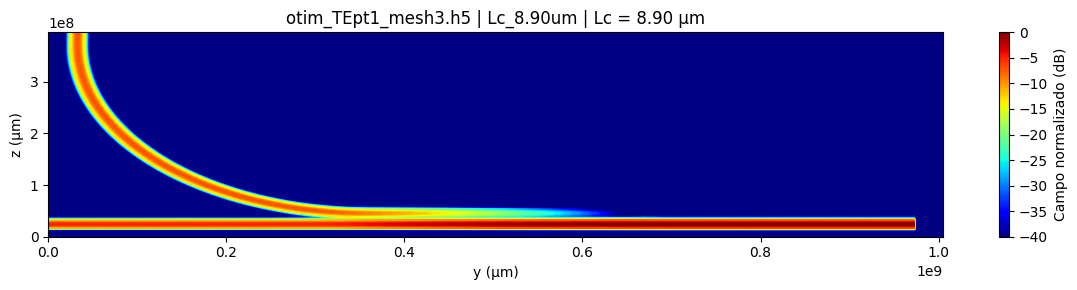

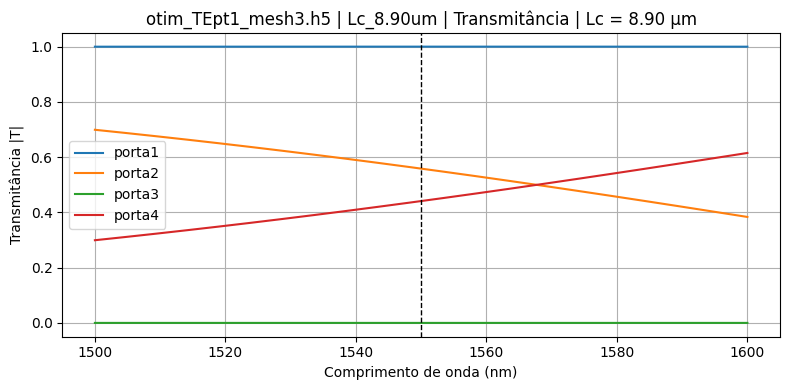

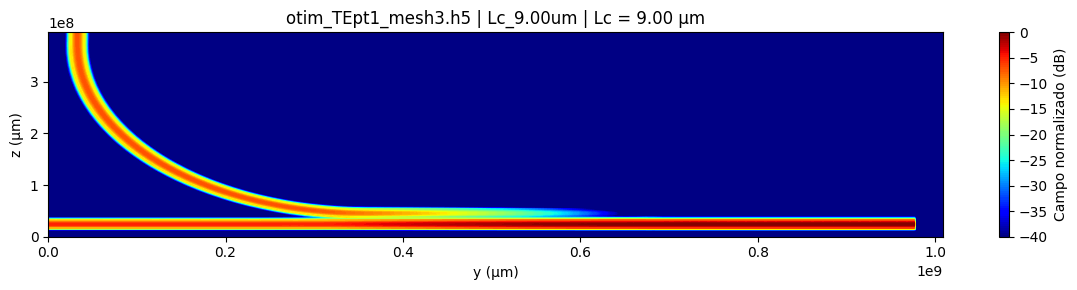

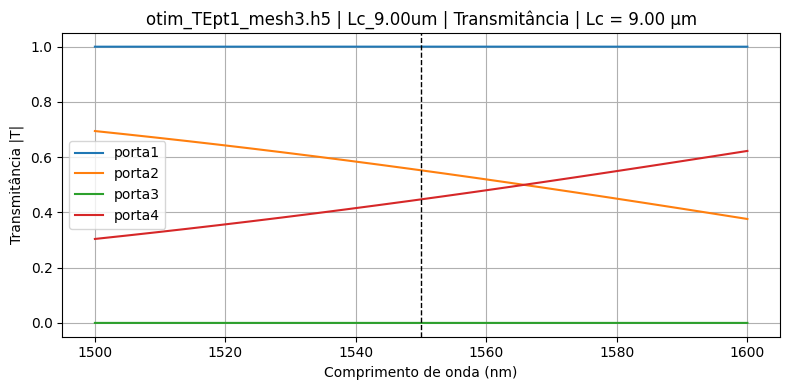

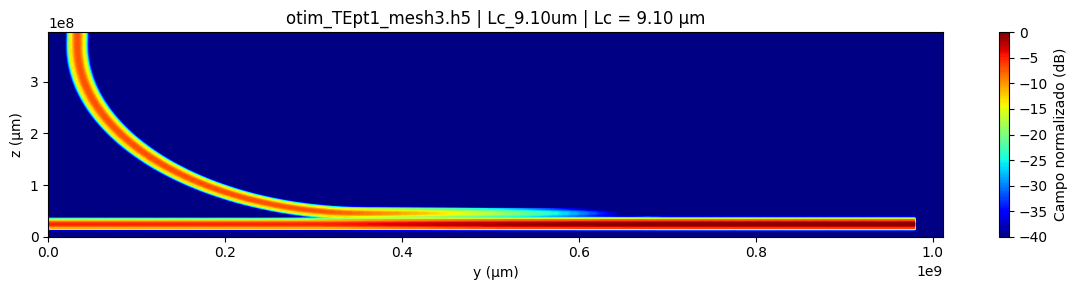

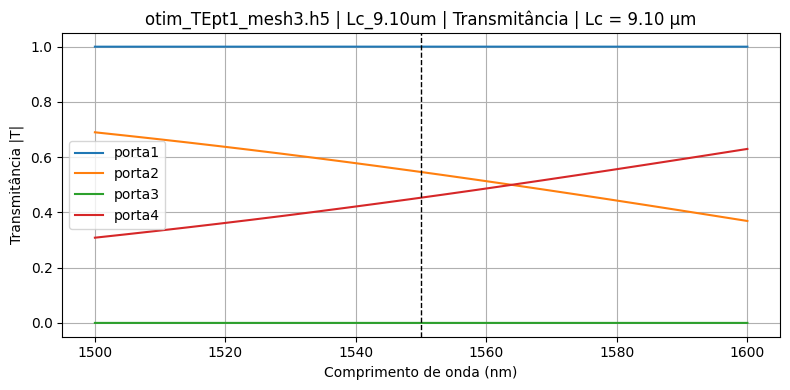

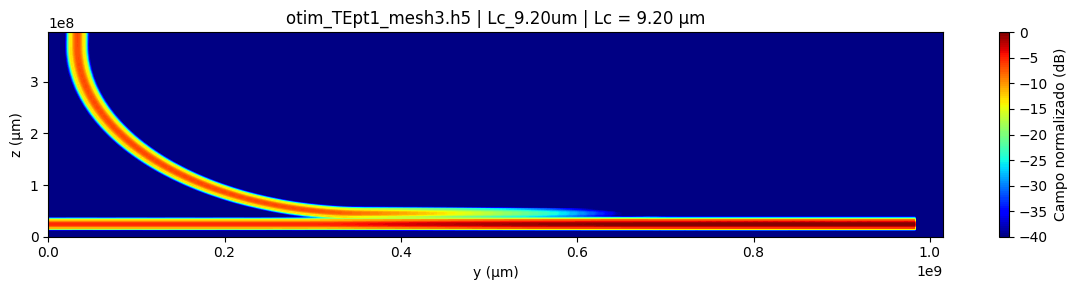

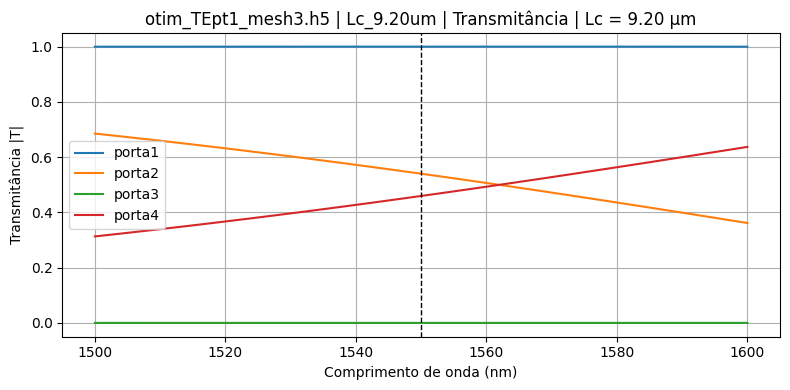

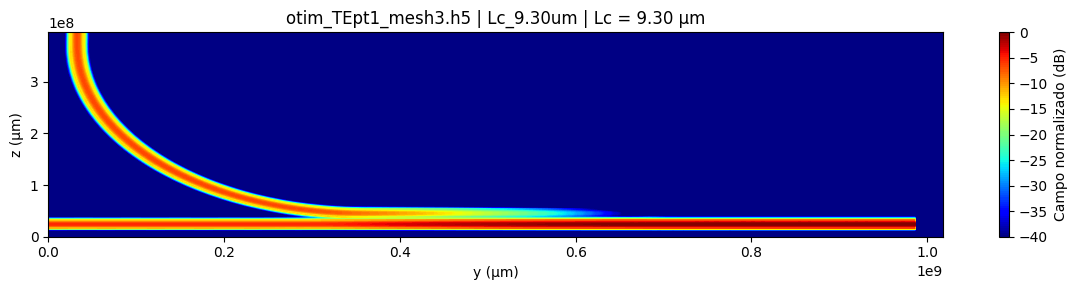

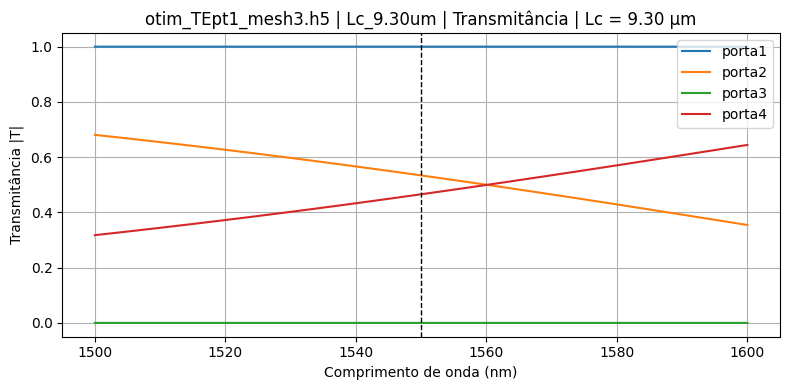

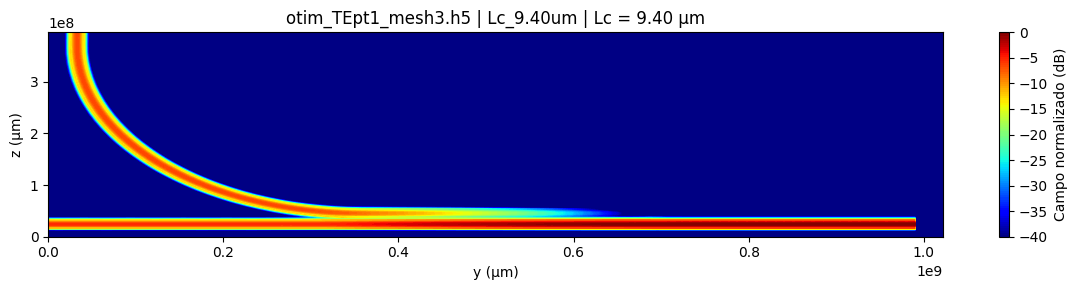

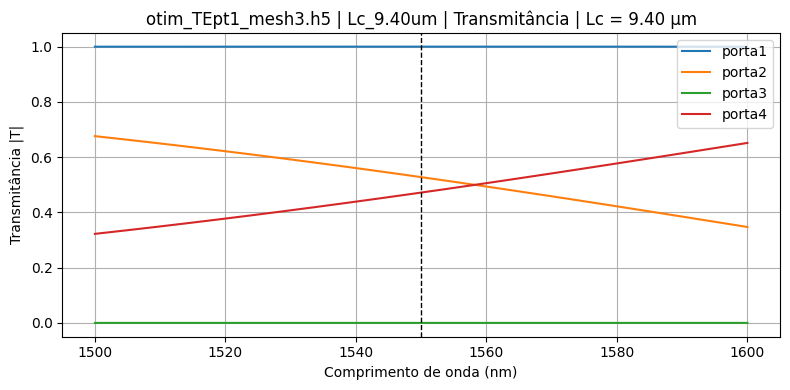

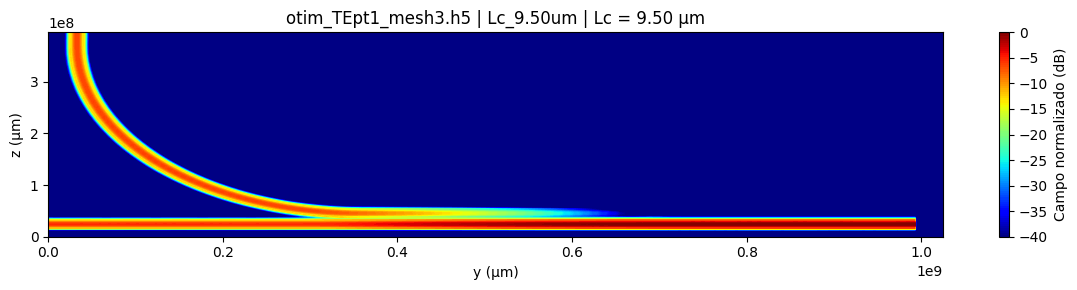

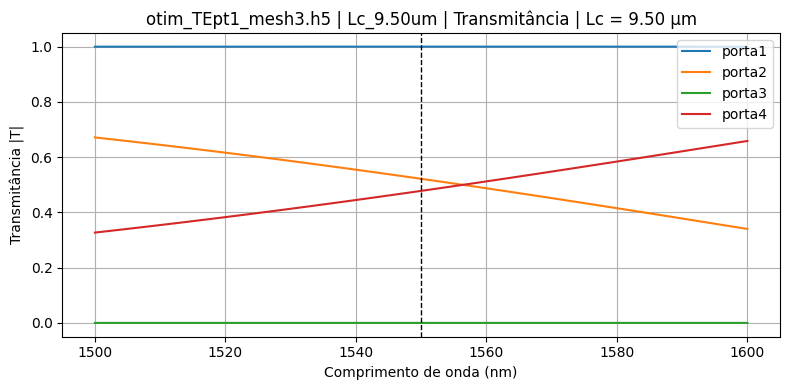

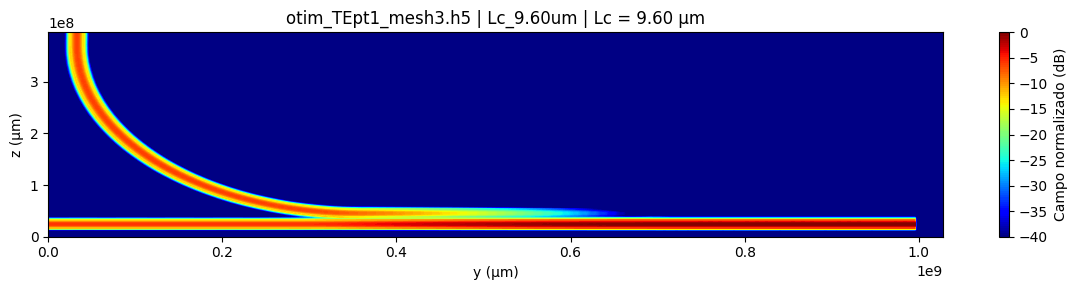

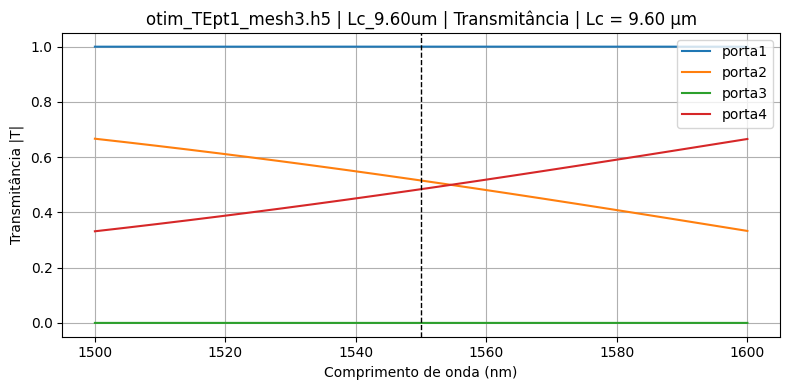

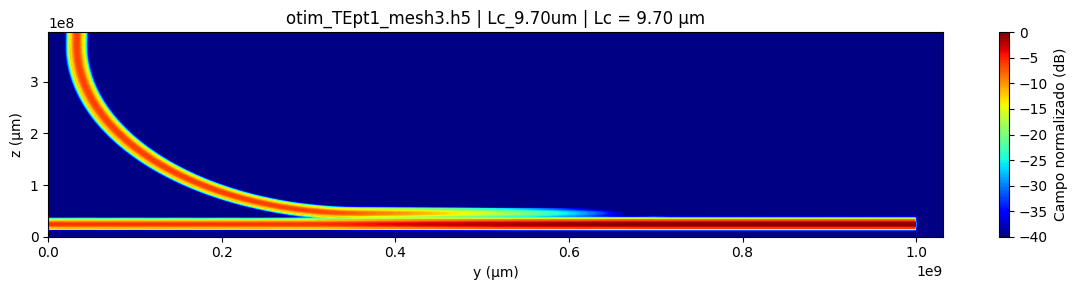

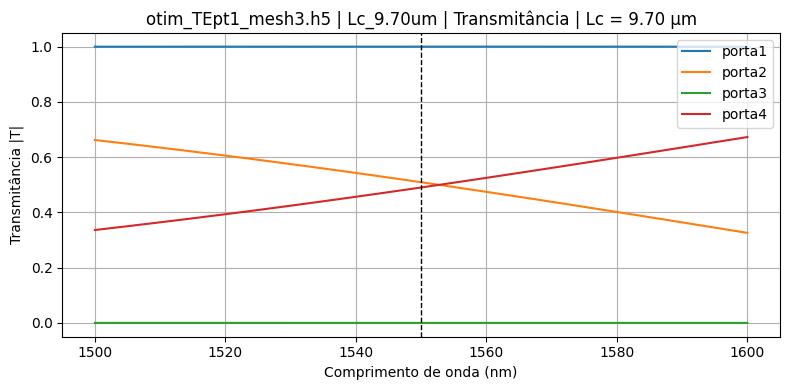

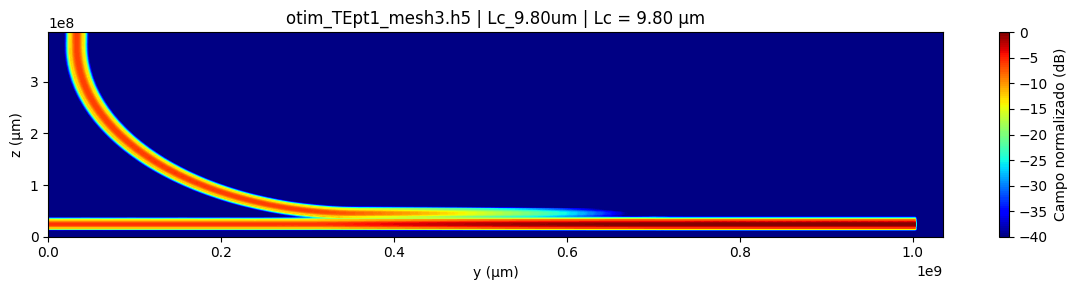

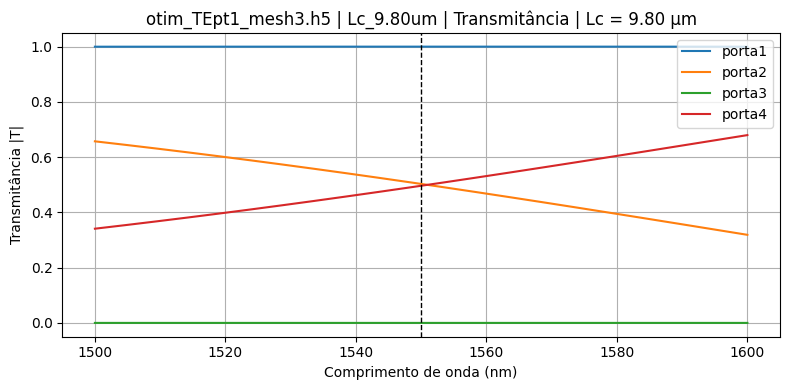

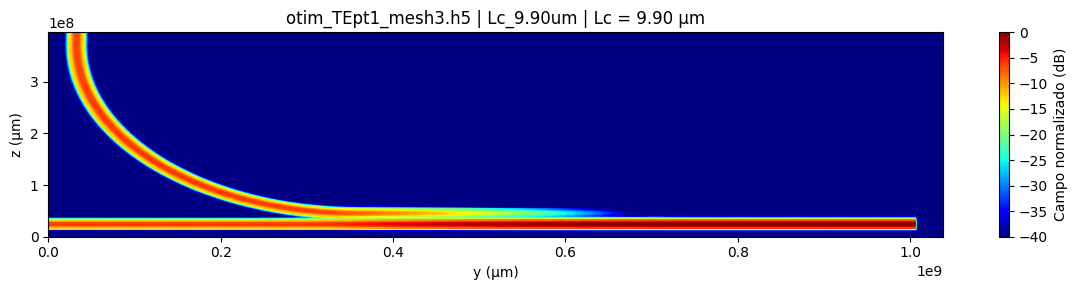

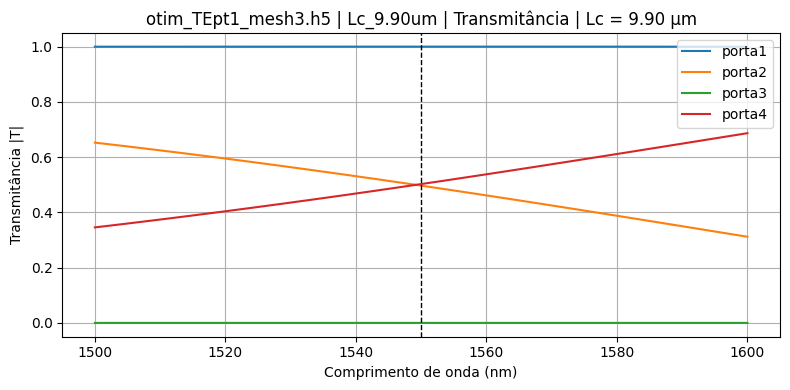


Processando: otim_TEpt2_mesh4.h5


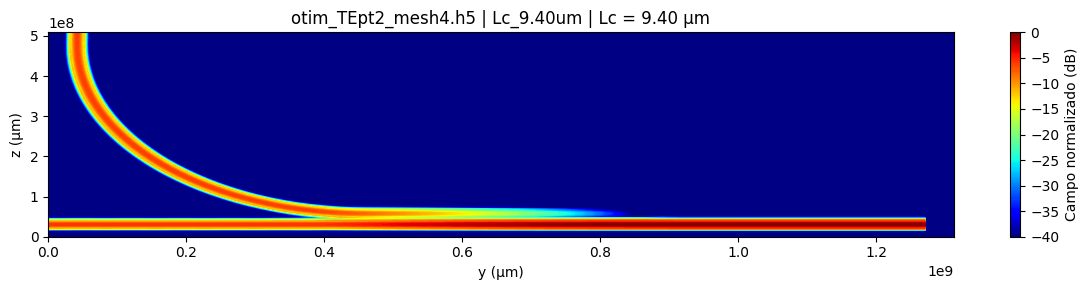

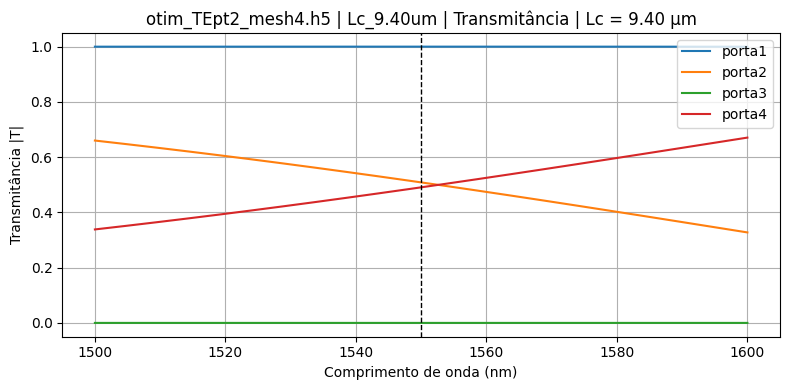

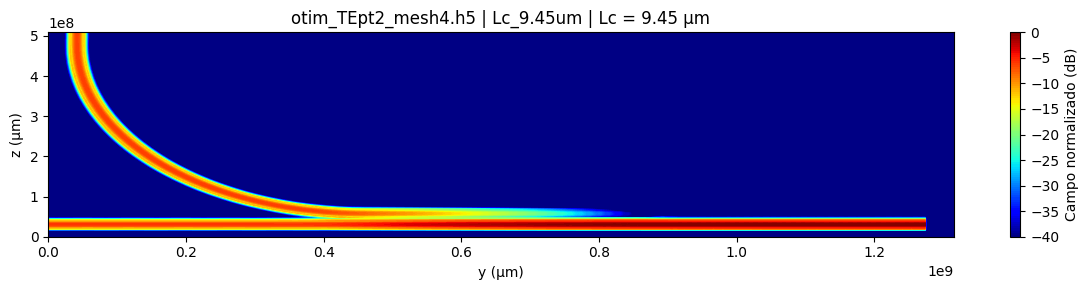

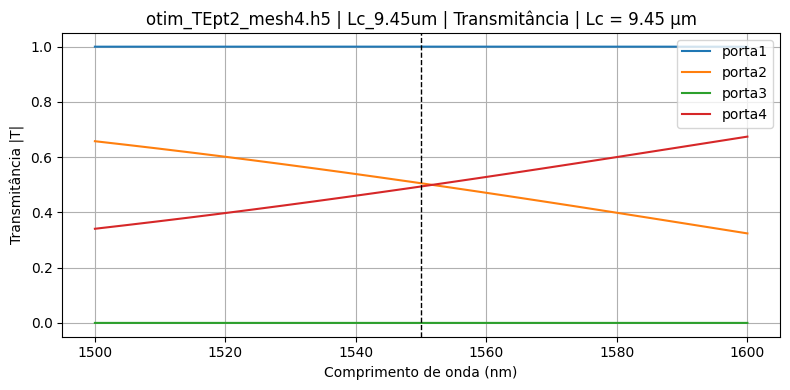

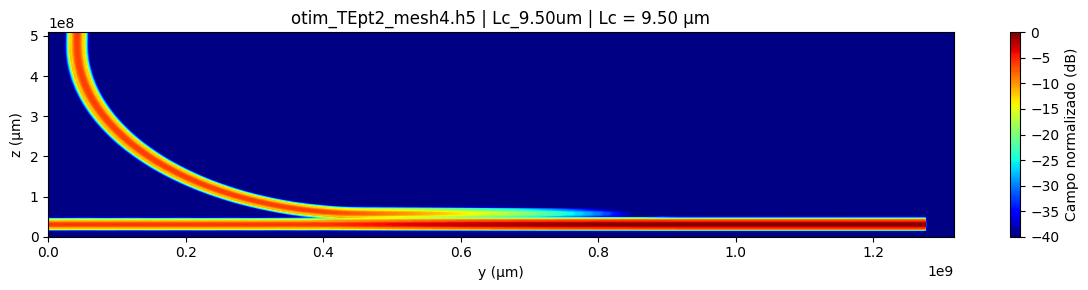

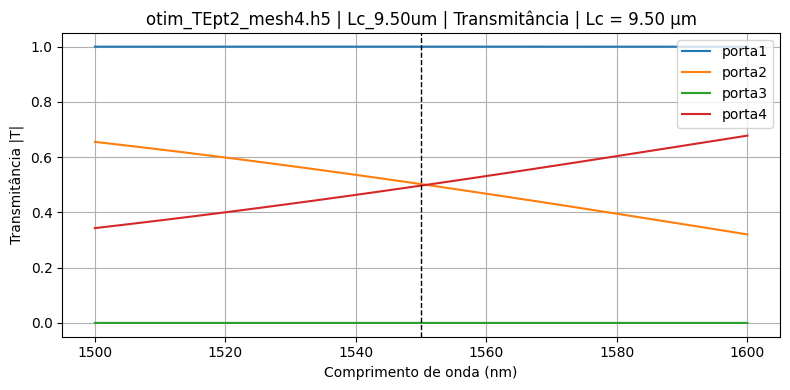

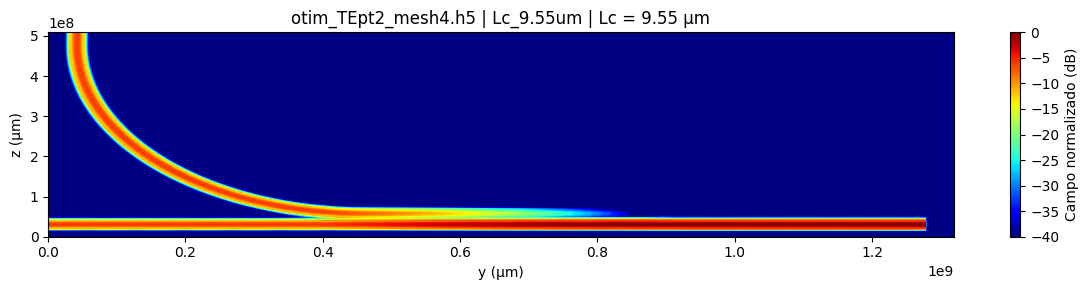

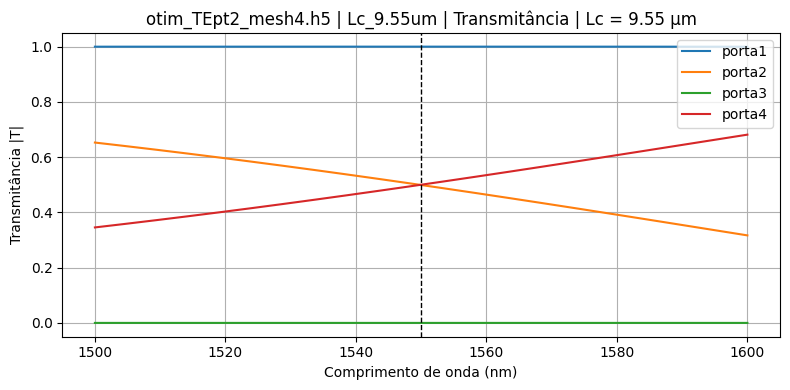

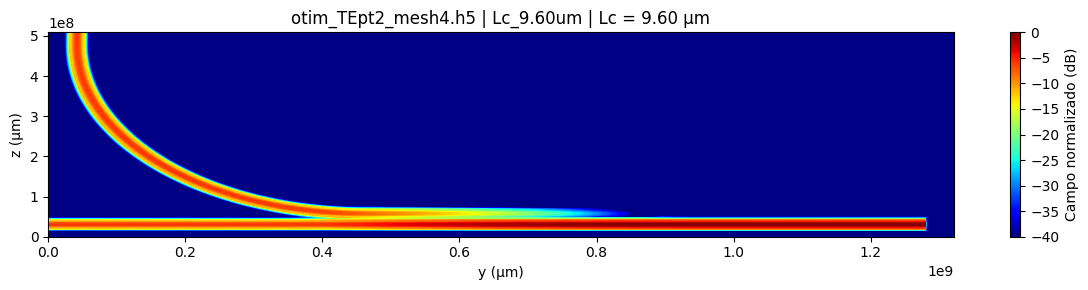

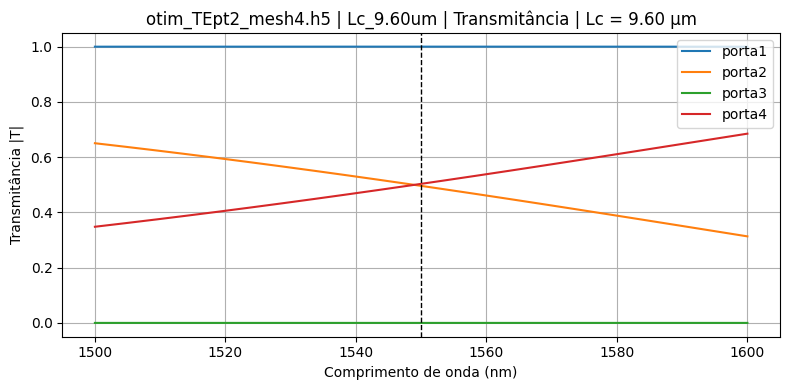

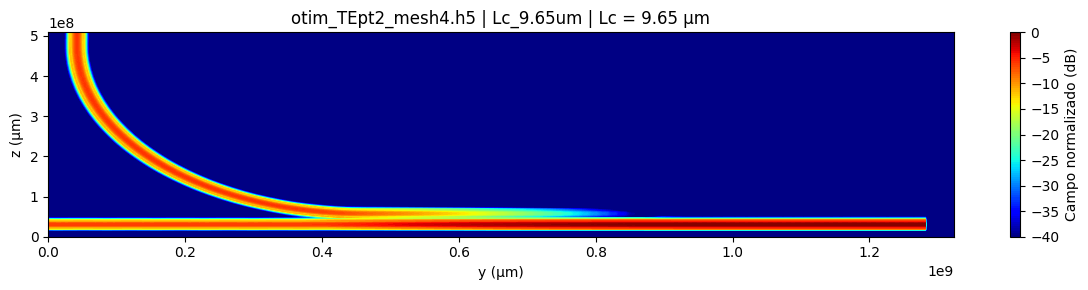

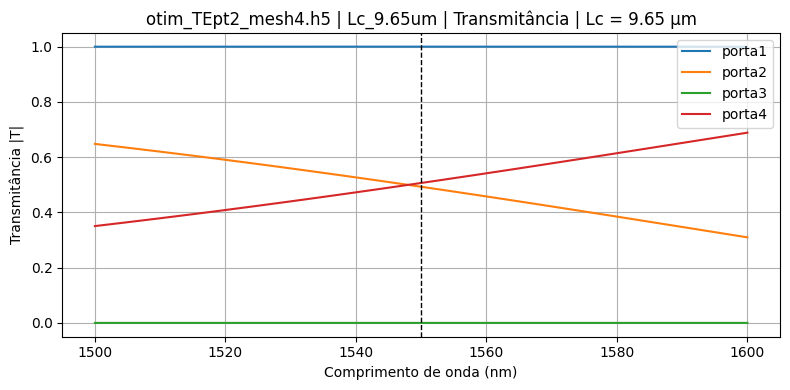


Processando: otim_TMp2.h5


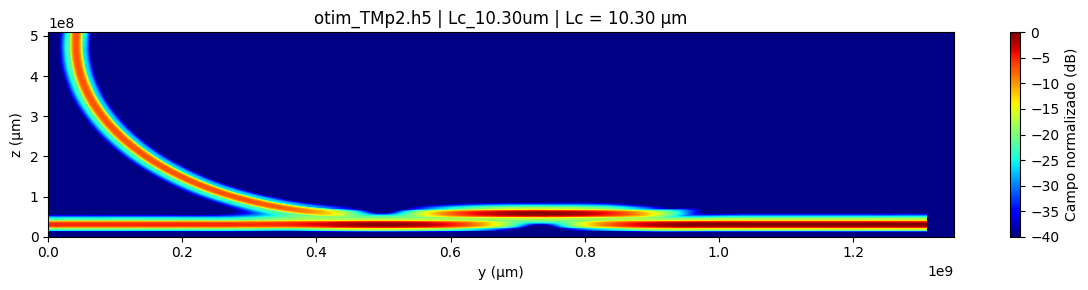

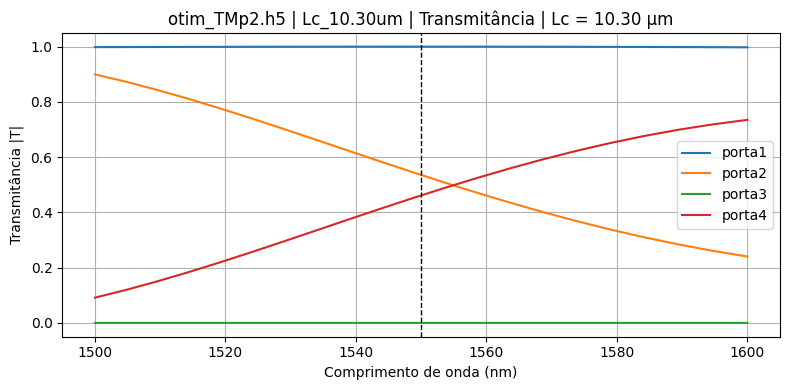

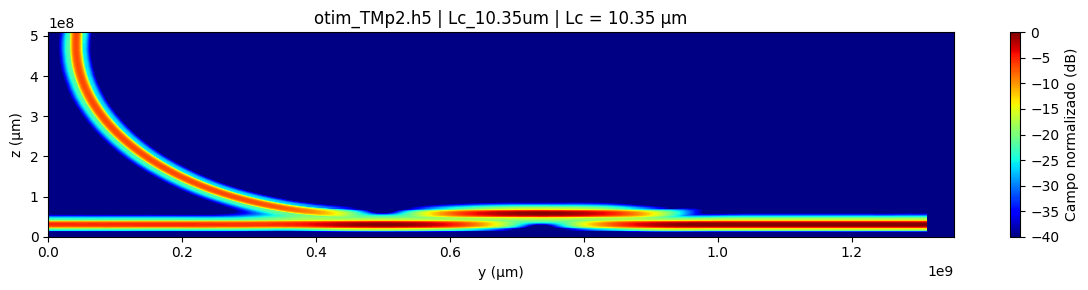

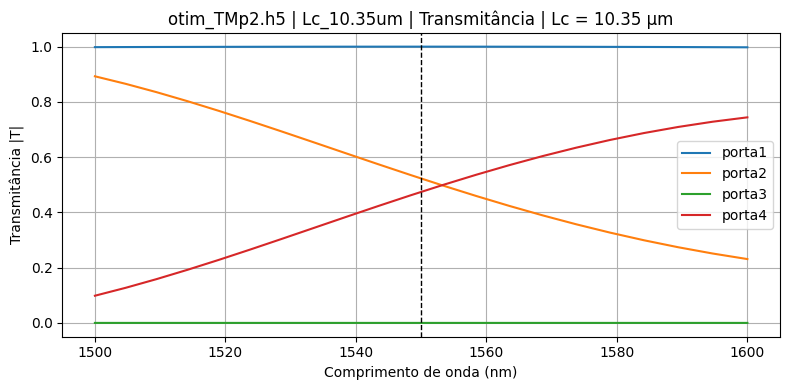

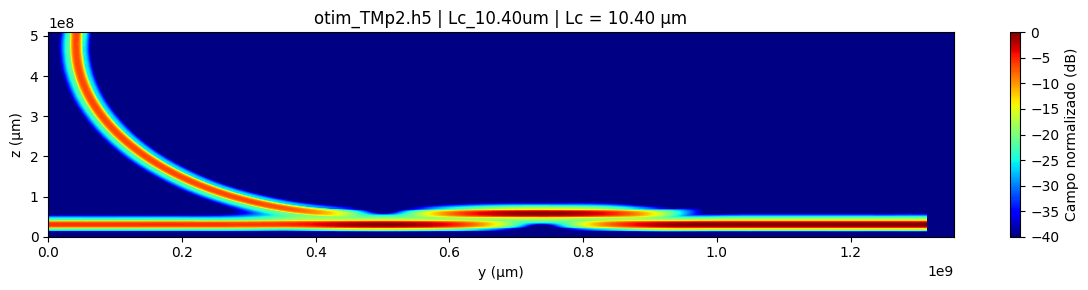

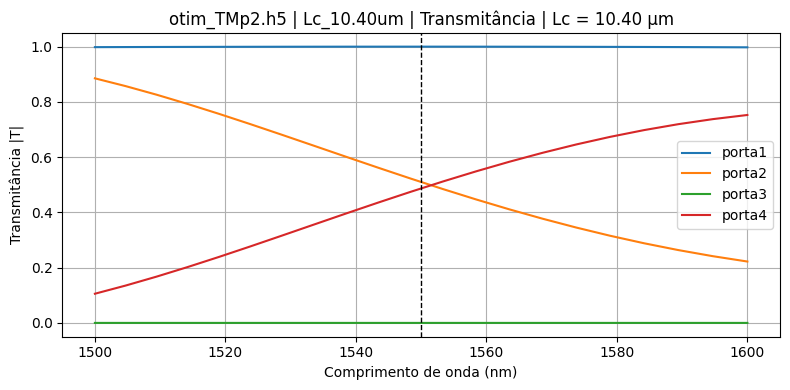

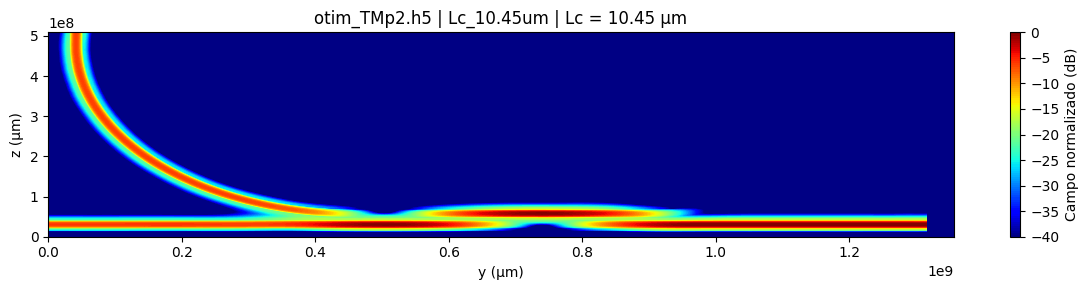

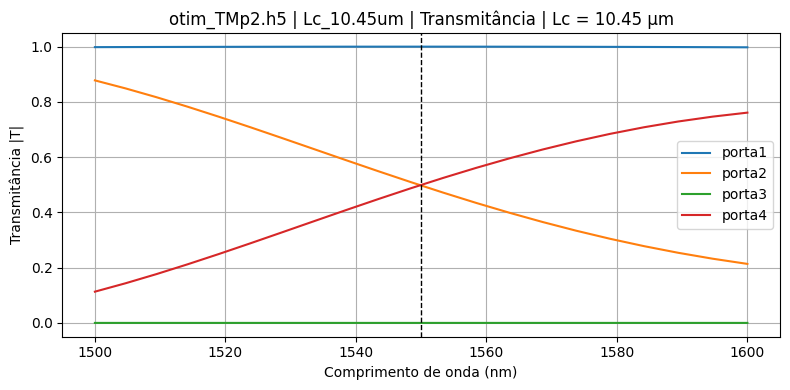


Processando: otim_TMpt1.h5


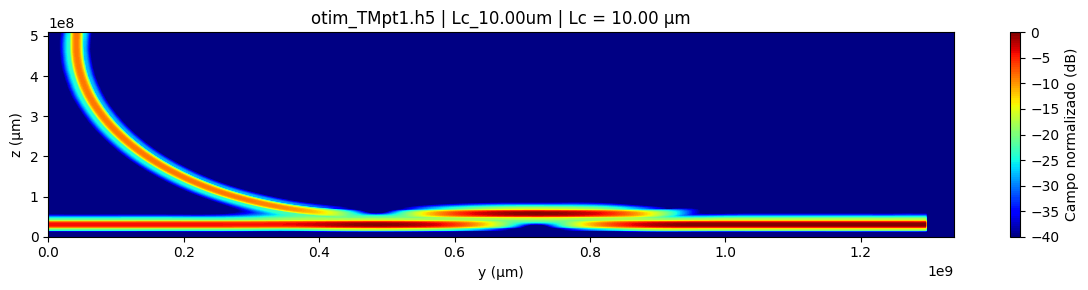

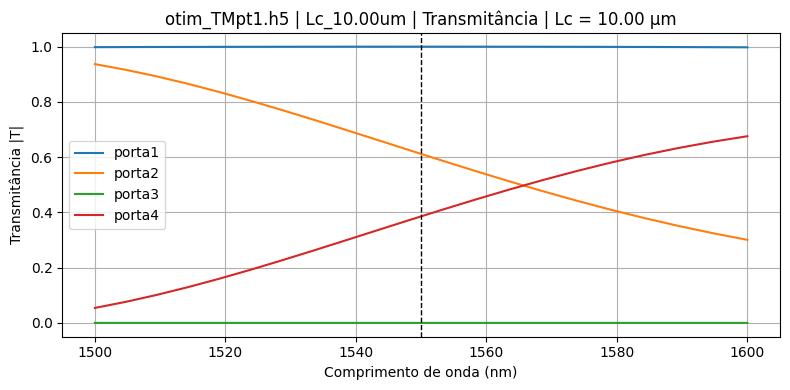

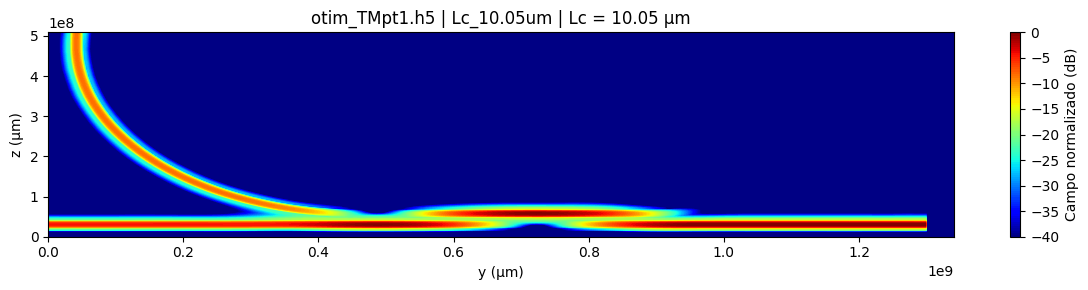

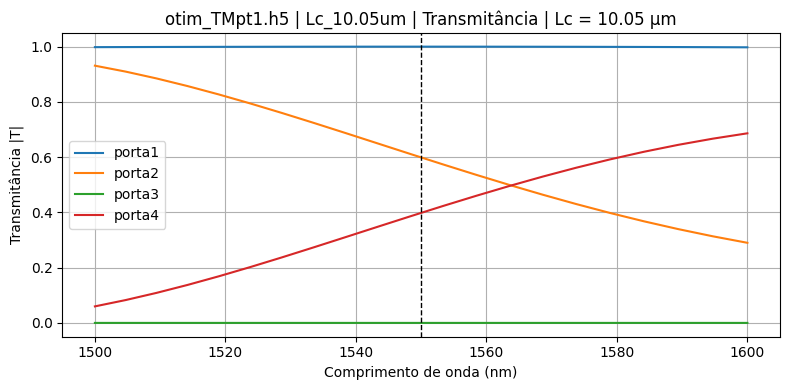

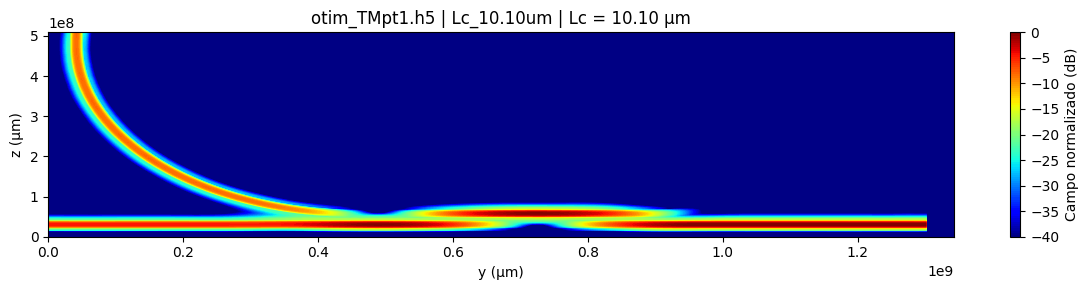

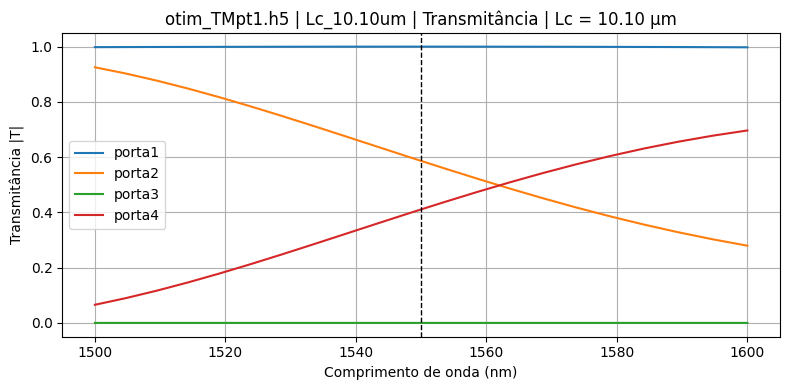

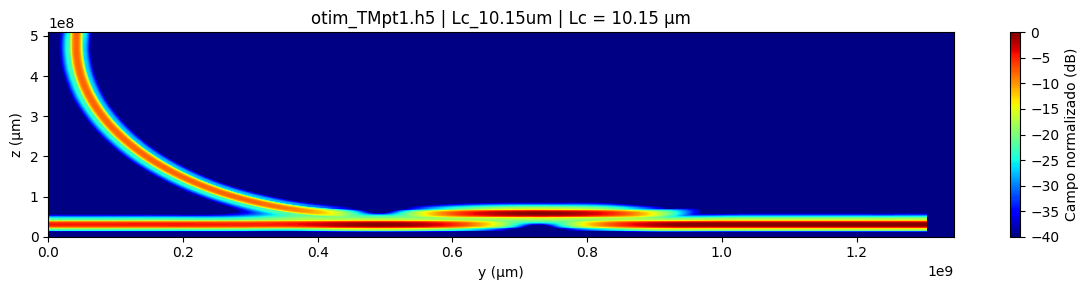

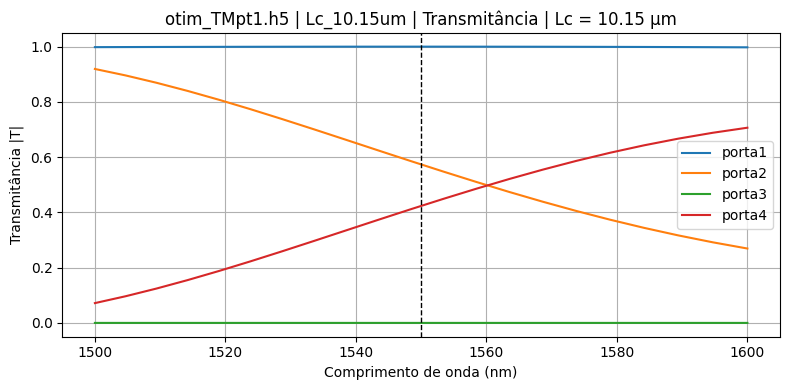

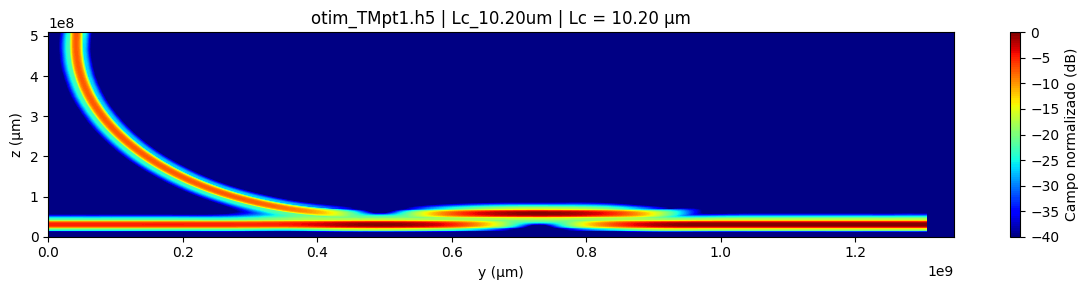

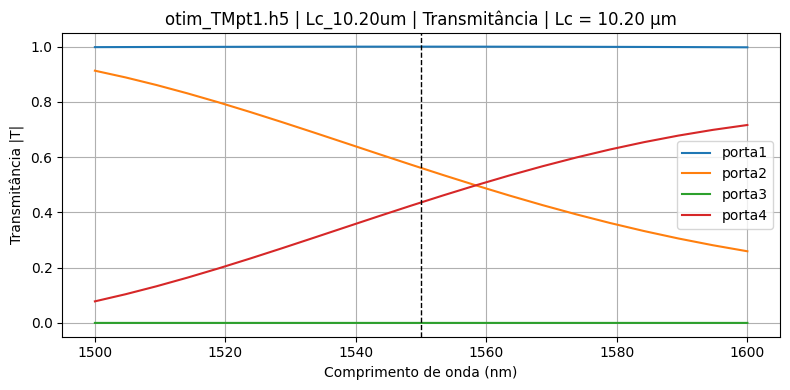

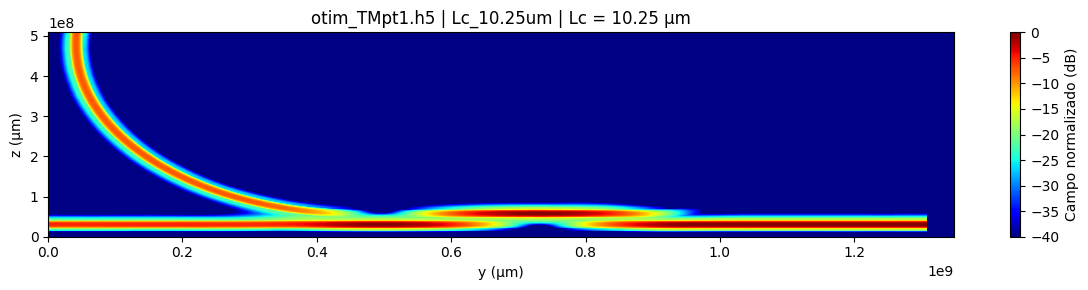

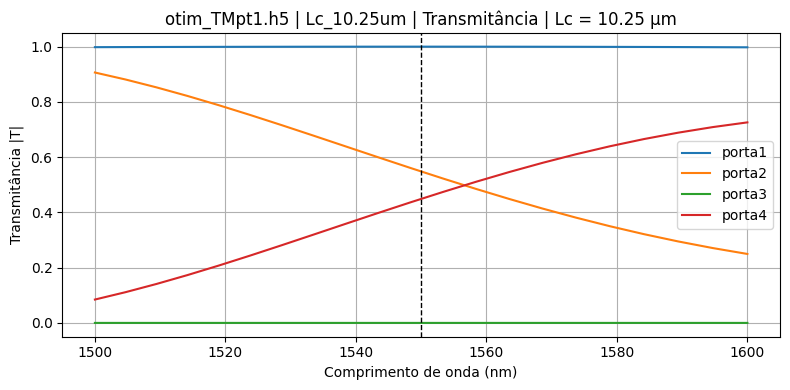

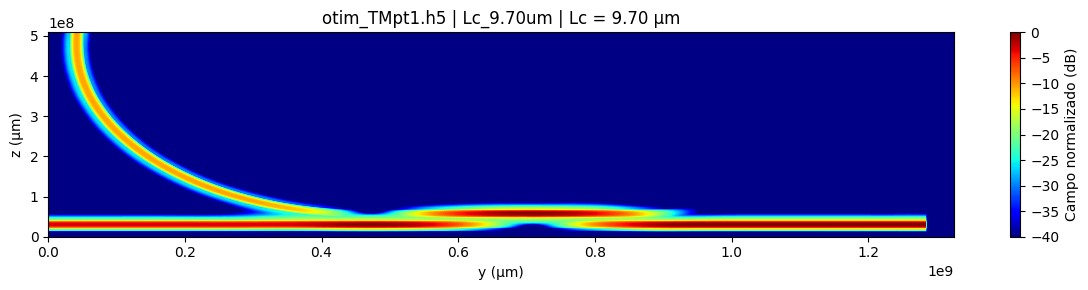

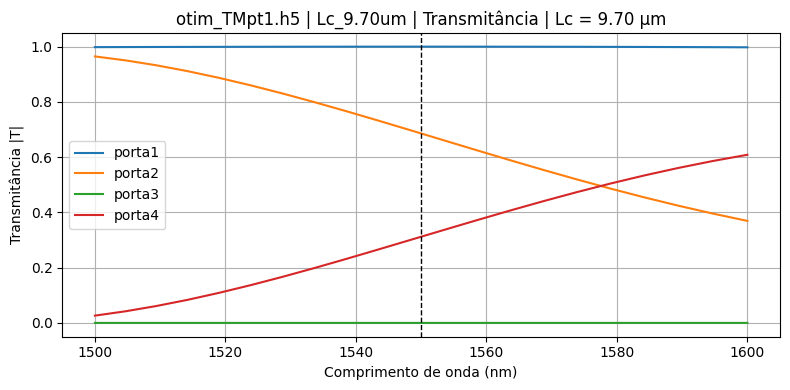

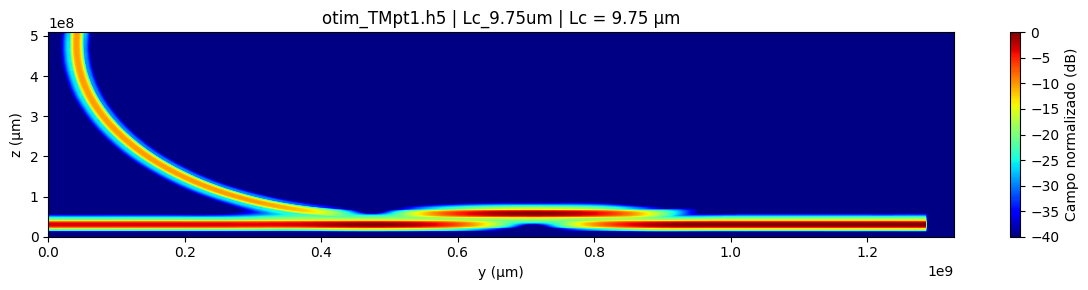

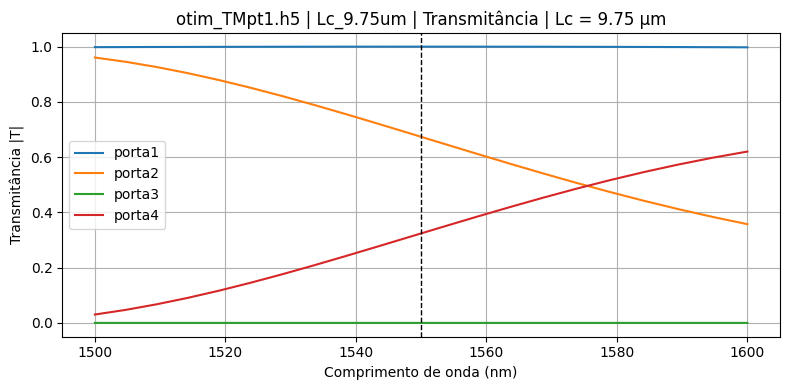

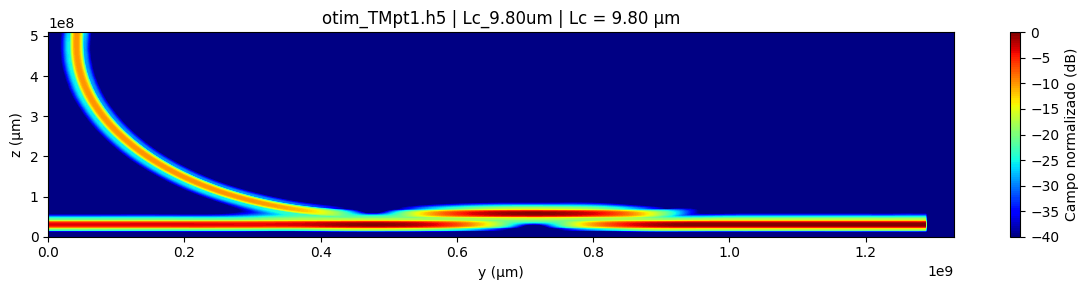

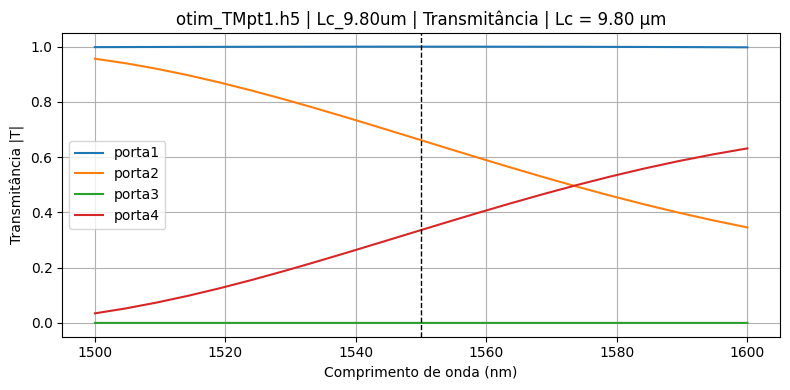

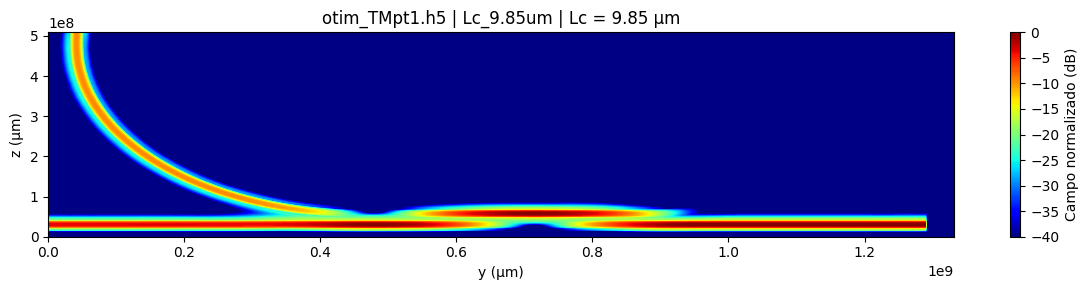

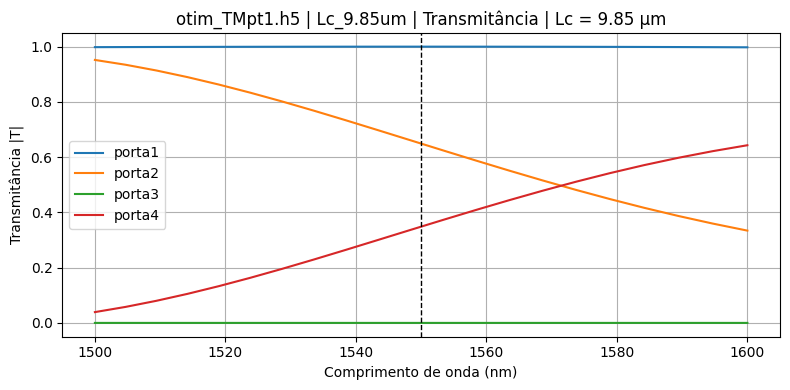

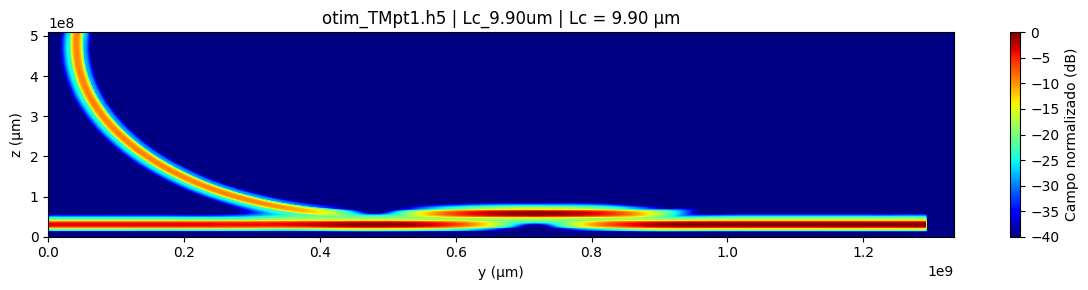

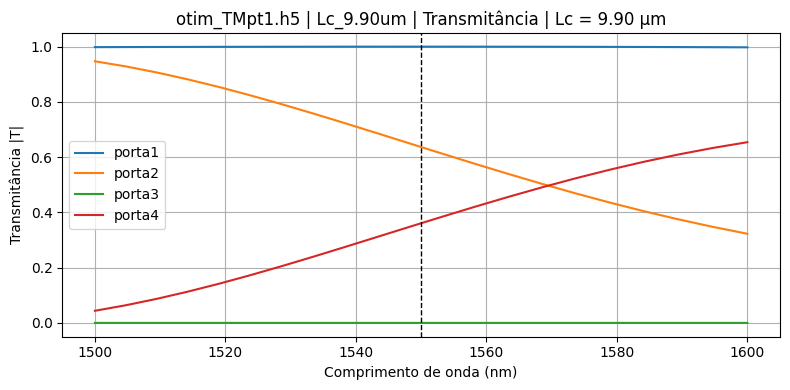

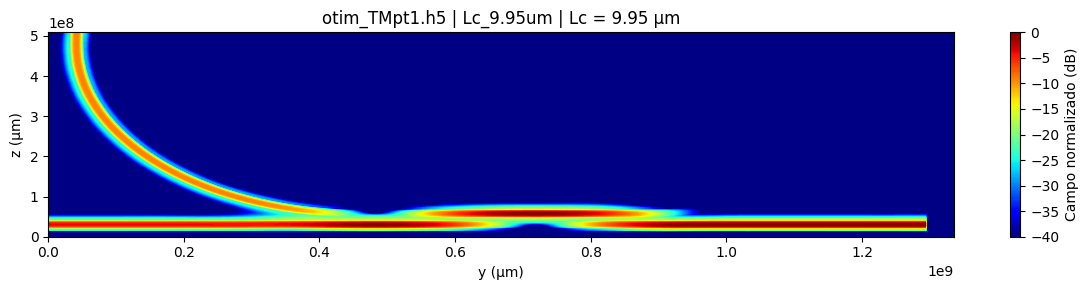

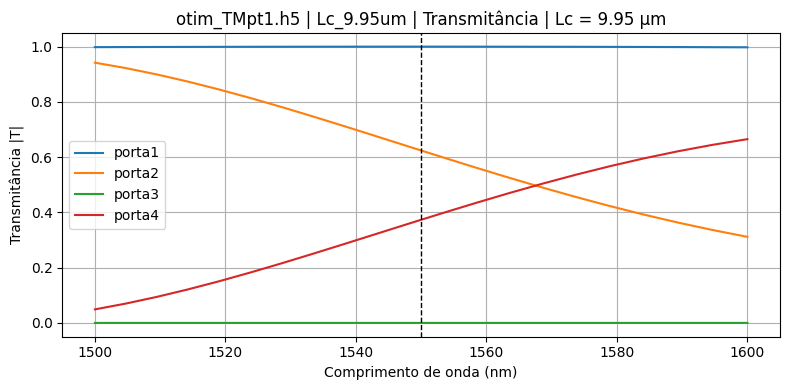

In [264]:
import re

# Pasta com os arquivos .h5
pasta_h5 = "h5"

def _extrair_lc_texto(texto):
    m = re.search(r"Lc[_=]?(\d+(?:\.\d+)?)\s*um", texto, flags=re.IGNORECASE)
    return f"{m.group(1)} µm" if m else None

def _ajustar_shape_campo(campo, eixo_y, eixo_z):
    campo = np.squeeze(campo)
    eixo_y = np.squeeze(eixo_y)
    eixo_z = np.squeeze(eixo_z)

    if campo.ndim != 2:
        return campo, eixo_y, eixo_z

    if campo.shape == (len(eixo_y), len(eixo_z)):
        return campo, eixo_y, eixo_z
    if campo.shape == (len(eixo_z), len(eixo_y)):
        return campo.T, eixo_y, eixo_z
    return campo, eixo_y, eixo_z

def plotar_perfil_campo_dB_titulo(eixo_y, eixo_z, campo, titulo, vmin=-40, vmax=0, cmap="jet"):
    fig = plt.figure(figsize=(12, 3))
    ax = fig.add_subplot(111)

    campo, eixo_y, eixo_z = _ajustar_shape_campo(campo, eixo_y, eixo_z)
    Z, Y = np.meshgrid(eixo_z * 1e6, eixo_y * 1e6)

    campo_abs = np.abs(campo)
    campo_abs = campo_abs / np.max(campo_abs)
    campo_db = 10 * np.log10(campo_abs + 1e-30)
    campo_db = np.clip(campo_db, vmin, vmax)

    levels = np.linspace(vmin, vmax, 100)
    contour = ax.contourf(Y, Z, campo_db, levels=levels, cmap=cmap)

    ax.set_xlabel("y (µm)")
    ax.set_ylabel("z (µm)")
    ax.set_title(titulo)

    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_ticks(np.arange(vmin, vmax + 1, 5))
    cbar.set_label("Campo normalizado (dB)")

    plt.tight_layout()
    plt.show()

def plotar_transmitancia_titulo(portas_grp, titulo):
    portas_keys = sorted([k for k in portas_grp.keys() if k.lower().startswith("porta")])
    if not portas_keys:
        return False

    plt.figure(figsize=(8, 4))
    for p in portas_keys:
        pgrp = portas_grp[p]
        if "lambda" in pgrp and "T" in pgrp:
            lmbd = np.squeeze(pgrp["lambda"][:]) * 1e9  # nm
            T = np.squeeze(pgrp["T"][:])
            plt.plot(lmbd, np.abs(T), label=p)

    plt.axvline(1550, color="k", linestyle="--", linewidth=1)
    plt.xlabel("Comprimento de onda (nm)")
    plt.ylabel("Transmitância |T|")
    plt.title(titulo)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return True

arquivos_h5 = sorted(
    [arq for arq in os.listdir(pasta_h5) if arq.lower().endswith(".h5")]
)

if not arquivos_h5:
    print(f"Nenhum arquivo .h5 encontrado em: {pasta_h5}")
else:
    for arq in arquivos_h5:
        caminho = os.path.join(pasta_h5, arq)
        base = os.path.basename(arq)
        print(f"\nProcessando: {base}")

        with h5py.File(caminho, "r") as hf:
            plotou = False

            # Caso 1: grupos no formato Lc_XX.XXum
            for key in hf.keys():
                if key.lower().startswith("lc_") and isinstance(hf[key], h5py.Group):
                    grp = hf[key]

                    # Campo
                    if "e_field" in grp:
                        campo = grp["e_field"][:]
                        if "x" in grp and "y" in grp:
                            eixo_y = grp["x"][:]
                            eixo_z = grp["y"][:]
                        else:
                            eixo_y = np.arange(campo.shape[0])
                            eixo_z = np.arange(campo.shape[1])

                        lc_txt = _extrair_lc_texto(key) or "Lc não identificado"
                        titulo = f"{base} | {key} | Lc = {lc_txt}"
                        plotar_perfil_campo_dB_titulo(eixo_y, eixo_z, campo, titulo)
                        plotou = True

                    # T por porta
                    if "portas" in grp:
                        lc_txt = _extrair_lc_texto(key) or "Lc não identificado"
                        titulo_T = f"{base} | {key} | Transmitância | Lc = {lc_txt}"
                        plotar_transmitancia_titulo(grp["portas"], titulo_T)
                        plotou = True

            # Caso 2: estrutura simulacoes_50_fde_FDTD
            if "simulacoes_50_fde_FDTD" in hf:
                grp = hf["simulacoes_50_fde_FDTD"]

                # Campo
                if "field" in grp and "field_E" in grp["field"]:
                    field_grp = grp["field"]
                    campo = field_grp["field_E"][:]
                    eixo_y = field_grp["x"][:] if "x" in field_grp else np.arange(campo.shape[0])
                    eixo_z = field_grp["y"][:] if "y" in field_grp else np.arange(campo.shape[1])

                    lc_txt = _extrair_lc_texto(base) or "Lc não identificado"
                    titulo = f"{base} | Lc = {lc_txt}"
                    plotar_perfil_campo_dB_titulo(eixo_y, eixo_z, campo, titulo)
                    plotou = True

                # T por porta
                if "portas" in grp:
                    lc_txt = _extrair_lc_texto(base) or "Lc não identificado"
                    titulo_T = f"{base} | Transmitância | Lc = {lc_txt}"
                    plotar_transmitancia_titulo(grp["portas"], titulo_T)
                    plotou = True

            if not plotou:
                print(f"  Estrutura não reconhecida para campo/T em: {base}")

In [332]:
np.linspace(8.5e-6, 9.9e-6, 15)

array([8.5e-06, 8.6e-06, 8.7e-06, 8.8e-06, 8.9e-06, 9.0e-06, 9.1e-06,
       9.2e-06, 9.3e-06, 9.4e-06, 9.5e-06, 9.6e-06, 9.7e-06, 9.8e-06,
       9.9e-06])

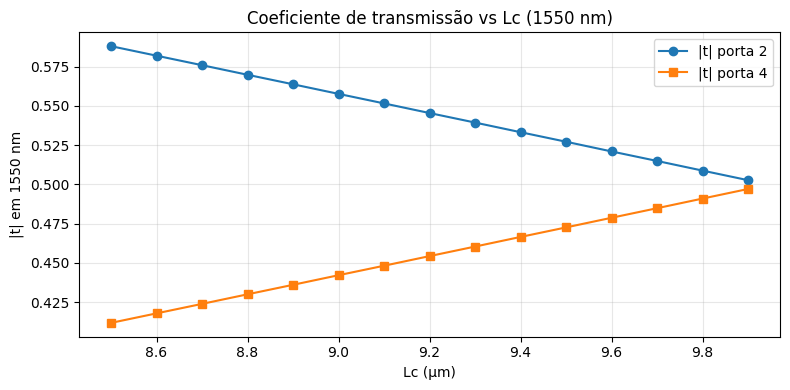

In [338]:
arquivo_analise_T_Lc = "h5\\otim_TEpt1_mesh3.h5"

# Coletar dados de todas as simulações no estudo
lc_values = np.linspace(8.5e-6, 9.9e-6, 15)
t_values_porta2 = []
t_values_porta4 = []
with h5py.File(arquivo_analise_T_Lc, "r") as hf:
    for lc in lc_values:
        nome_grupo = f"Lc_{lc*1e6:.2f}um"

        if nome_grupo not in hf:
            t_values_porta2.append(np.nan)
            t_values_porta4.append(np.nan)
            continue

        portas = hf[nome_grupo]["portas"]

        lambda_ref = np.squeeze(portas["porta2"]["lambda"][:])
        idx_1550 = np.argmin(np.abs(lambda_ref - 1.55e-6))

        T2 = np.squeeze(portas["porta2"]["T"][:])
        T4 = np.squeeze(portas["porta4"]["T"][:])

        t_values_porta2.append(np.abs(T2[idx_1550]))
        t_values_porta4.append(np.abs(T4[idx_1550]))

t_values_porta2 = np.array(t_values_porta2)
t_values_porta4 = np.array(t_values_porta4)

plt.figure(figsize=(8, 4))
plt.plot(lc_values * 1e6, t_values_porta2, marker="o", label="|t| porta 2")
plt.plot(lc_values * 1e6, t_values_porta4, marker="s", label="|t| porta 4")
plt.xlabel("Lc (µm)")
plt.ylabel("|t| em 1550 nm")
plt.title("Coeficiente de transmissão vs Lc (1550 nm)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("transmissao_vs_Lc_TE_pt1.png", dpi=300)
plt.show()


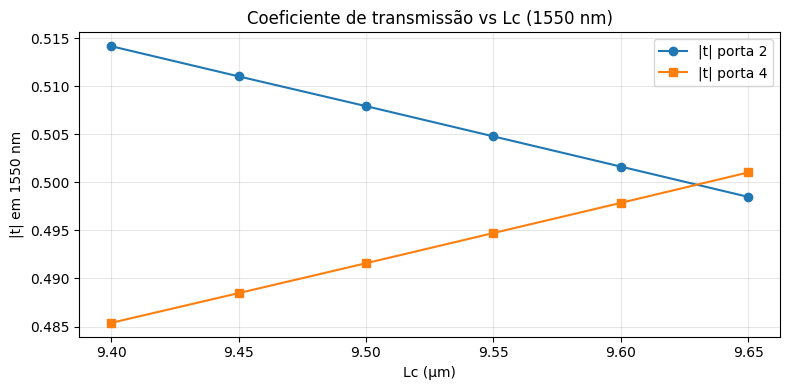

In [337]:
arquivo_analise_T_Lc = "h5\\otim_TEpt2_mesh4.h5"

# Coletar dados de todas as simulações no estudo
lc_values = np.linspace(9.4e-6, 9.65e-6, 6)
t_values_porta2 = []
t_values_porta4 = []


with h5py.File(arquivo_analise_T_Lc, "r") as hf:
    for lc in lc_values:
        nome_grupo = f"Lc_{lc*1e6:.2f}um"

        if nome_grupo not in hf:
            t_values_porta2.append(np.nan)
            t_values_porta4.append(np.nan)
            continue

        portas = hf[nome_grupo]["portas"]

        lambda_ref = np.squeeze(portas["porta2"]["lambda"][:])
        idx_1550 = np.argmin(np.abs(lambda_ref - 1.55e-6))

        T2 = np.squeeze(portas["porta2"]["T"][:])
        T4 = np.squeeze(portas["porta4"]["T"][:])

        t_values_porta2.append(np.abs(T2[idx_1550]))
        t_values_porta4.append(np.abs(T4[idx_1550]))

t_values_porta2 = np.array(t_values_porta2)
t_values_porta4 = np.array(t_values_porta4)

plt.figure(figsize=(8, 4))
plt.plot(lc_values * 1e6, t_values_porta2, marker="o", label="|t| porta 2")
plt.plot(lc_values * 1e6, t_values_porta4, marker="s", label="|t| porta 4")
plt.xlabel("Lc (µm)")
plt.ylabel("|t| em 1550 nm")
plt.title("Coeficiente de transmissão vs Lc (1550 nm)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("transmissao_vs_Lc_TE_pt2.png", dpi=300)
plt.show()


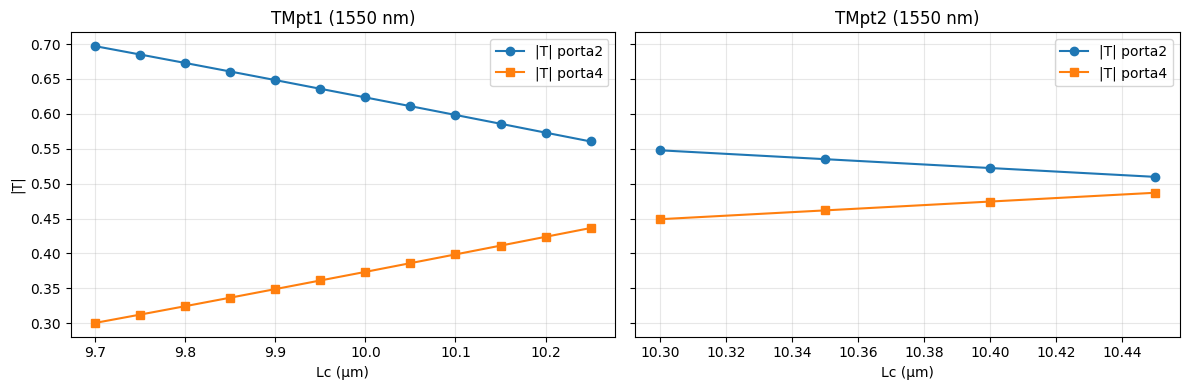


TMpt1:
[[ 9.7         0.69695972  0.30041371]
 [ 9.75        0.68494941  0.31233247]
 [ 9.8         0.67284473  0.3243881 ]
 [ 9.85        0.66061603  0.33657319]
 [ 9.9         0.64832107  0.34885628]
 [ 9.95        0.635865    0.36121343]
 [10.          0.62350166  0.37352025]
 [10.05        0.6109747   0.38603803]
 [10.1         0.59839415  0.39854232]
 [10.15        0.58578326  0.41111885]
 [10.2         0.57304814  0.4237587 ]
 [10.25        0.56041679  0.43634913]]

TMpt2:
[[10.3         0.54773998  0.44899247]
 [10.35        0.53501552  0.46162664]
 [10.4         0.52233205  0.47429089]
 [10.45        0.50965972  0.48690041]]


In [ ]:
# Coletar |T| em 1550 nm vs Lc para TMpt1 e TMpt2

def _resolver_arquivo_h5(candidatos, pasta="h5"):
    for nome in candidatos:
        caminho = os.path.join(pasta, nome)
        if os.path.exists(caminho):
            return caminho
    return None

def coletar_T_vs_Lc_1550(arquivo_h5, lc_values):
    t2_vals, t4_vals = [], []

    with h5py.File(arquivo_h5, "r") as hf:
        for lc in lc_values:
            grupo = f"Lc_{lc*1e6:.2f}um"

            if grupo not in hf:
                t2_vals.append(np.nan)
                t4_vals.append(np.nan)
                continue

            portas = hf[grupo]["portas"]

            lmbd = np.squeeze(portas["porta2"]["lambda"][:])
            idx_1550 = np.argmin(np.abs(lmbd - 1.55e-6))

            T2 = np.squeeze(portas["porta2"]["T"][:])
            T4 = np.squeeze(portas["porta4"]["T"][:])

            t2_vals.append(np.abs(T2[idx_1550]))
            t4_vals.append(np.abs(T4[idx_1550]))

    return np.array(t2_vals), np.array(t4_vals)

# Intervalos pedidos
lc_tmpt2 = np.arange(10.3e-6, 10.45e-6 + 1e-15, 0.05e-6)
lc_tmpt1 = np.arange(9.7e-6, 10.25e-6 + 1e-15, 0.05e-6)

# Resolver nomes de arquivo (com fallback)
arquivo_tmpt2 = _resolver_arquivo_h5([
    "otim_TMpt2_mesh4.h5", "otim_TMp2_mesh4.h5", "otim_TMpt2.h5", "otim_TMp2.h5"
], pasta=pasta_h5)

arquivo_tmpt1 = _resolver_arquivo_h5([
    "otim_TMpt1_mesh4.h5", "otim_TMpt1_mesh3.h5", "otim_TMpt1.h5"
], pasta=pasta_h5)

if arquivo_tmpt2 is None or arquivo_tmpt1 is None:
    print("Não foi possível localizar um ou ambos os arquivos TMpt1/TMpt2 na pasta:", pasta_h5)
else:
    t2_tmpt2, t4_tmpt2 = coletar_T_vs_Lc_1550(arquivo_tmpt2, lc_tmpt2)
    t2_tmpt1, t4_tmpt1 = coletar_T_vs_Lc_1550(arquivo_tmpt1, lc_tmpt1)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    ax[0].plot(lc_tmpt1 * 1e6, t2_tmpt1, "o-", label="|T| porta2")
    ax[0].plot(lc_tmpt1 * 1e6, t4_tmpt1, "s-", label="|T| porta4")
    ax[0].set_xlabel("Lc (µm)")
    ax[0].set_ylabel("|T|")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].plot(lc_tmpt2 * 1e6, t2_tmpt2, "o-", label="|T| porta2")
    ax[1].plot(lc_tmpt2 * 1e6, t4_tmpt2, "s-", label="|T| porta4")
    ax[1].set_xlabel("Lc (µm)")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    # Resumo numérico
    print("\nTMpt1:")
    print(np.column_stack([lc_tmpt1 * 1e6, t2_tmpt1, t4_tmpt1]))
    print("\nTMpt2:")
    print(np.column_stack([lc_tmpt2 * 1e6, t2_tmpt2, t4_tmpt2]))

In [349]:
# Dispositivo otimizado TE: Lc = 9.65 µm ; bc = Symmetric

Lc = 9.65e-6

time = (np.pi*curvatura + Lc)*7/c + 200e-15

# Variáveis FDTD: --------------------------------------------------------------
comprimento_guias_portas = 2e-6 

# Medidas do solver:
ganho_dist_ymin_bc = 2e-6
bSolver = 2*curvatura + Lc
hSolver = curvatura + 2*largura_guia + gap
y_solver = largura_guia + gap/2 + curvatura/2 - ganho_dist_ymin_bc/2

zSpan_solver = 4e-6
ySpan_solver = hSolver + ganho_dist_ymin_bc
xSpan_solver = bSolver + comprimento_guias_portas
bc_z = "Symmetric" # Symmetric (modo TE), Anti-symmetric (modo TM)
mesh_accuracy = 4


# Variáveis para construção das portas:
injection_axis = 'y-axis'
xb = bSolver/2
x_port = [xb, -xb, xb, -xb]
y_port = [-(gap + largura_guia)/2, -(gap + largura_guia)/2, (curvatura), (curvatura)]


lambda_i = 1500e-9
lambda_f = 1600e-9
qtd_pontos = 21
intervalo_lambda = np.linspace(lambda_i, lambda_f, qtd_pontos)


criar_acopladorDirecional(f, material_dispositivo, curvatura, altura_guia, largura_guia, gap, Lc, comprimento_guias_portas)

solverFDTD(f)

reset_view(f)

configurar_portas(f, modo)

add_monitor_xy(f)

checar_tamanho_simulacao(f)

f.save("acopladorDirecional_otimizado_TE2.fsp")

f.run()

f_x, f_y, field_E = extrair_perfil_campo_E(f)
T_portas = extrair_parametro_T(f)
filename = "acopladorDirecional_otimizado_TE_dados.h5"
with h5py.File(filename, 'w') as hf:
    fieldE = hf.create_group("field")
    fieldE.create_dataset("field_E", data=field_E)
    fieldE.create_dataset("x", data=f_x)
    fieldE.create_dataset("y", data=f_y)
    portas_grp = hf.create_group("portas")
    for idx, dados in enumerate(T_portas, start=1):
        pgrp = portas_grp.create_group(f"porta{idx}")
        pgrp.create_dataset("lambda", data=dados["lambda"])
        pgrp.create_dataset("T", data=dados["T"])



2625 MB


In [306]:
filename = "acopladorDirecional_otimizado_TE_dados.h5"

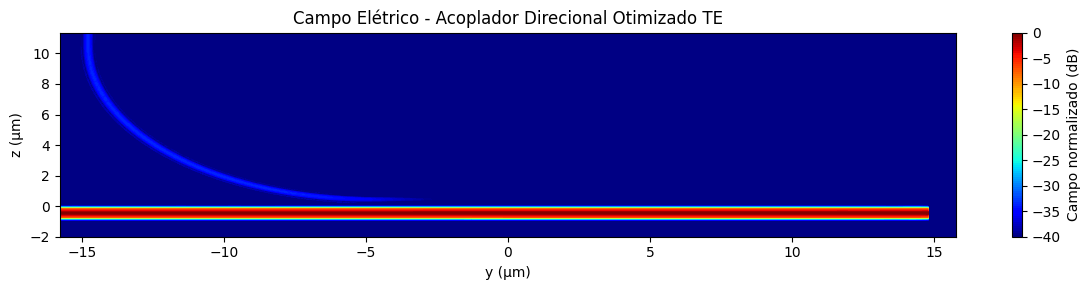

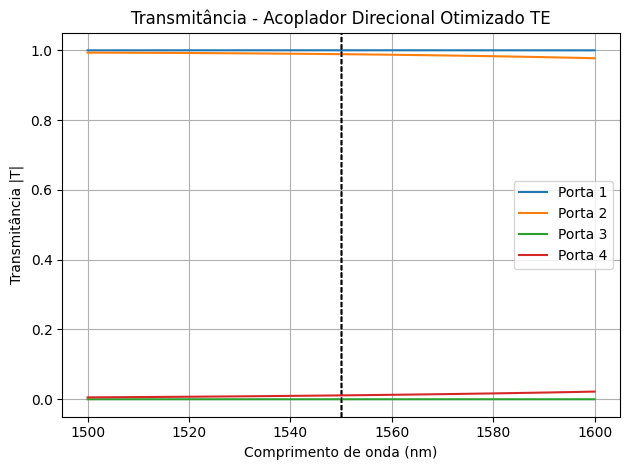

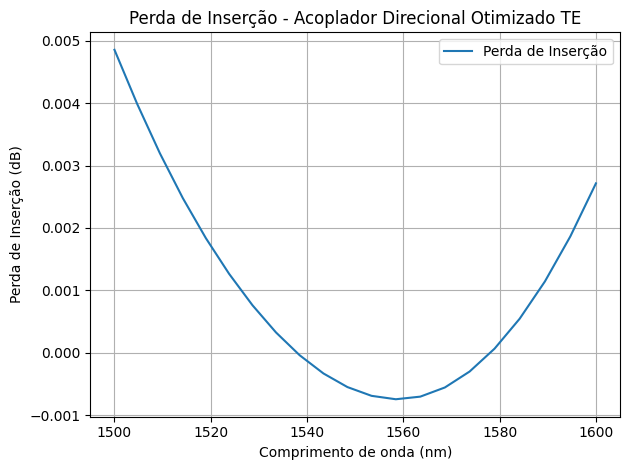

In [307]:

# Plotar campo, transmitância e perda de inserção:

with h5py.File(filename, "r") as hf:
    grp = hf["field"]
    x = grp["x"][:]
    y = grp["y"][:]
    e_field = grp["field_E"][:]
plotar_perfil_campo_dB_titulo(x, y, e_field, "Campo Elétrico - Acoplador Direcional Otimizado TE")

with h5py.File(filename, "r") as hf:
    portas = hf["portas"]
    for i in range(1, 5):
        pgrp = portas[f"porta{i}"]
        lmbd = pgrp["lambda"][:]
        T = pgrp["T"][:]
        plt.axvline(1550, color="k", linestyle="--", linewidth=1)
        plt.plot(lmbd*1e9, np.abs(T), label=f'Porta {i}')
plt.xlabel('Comprimento de onda (nm)')
plt.ylabel('Transmitância |T|')
plt.title('Transmitância - Acoplador Direcional Otimizado TE')
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()
with h5py.File(filename, "r") as hf:
    portas = hf["portas"]
    lmbd = portas["porta4"]["lambda"][:]
    T_porta4 = portas["porta4"]["T"][:]
    T_porta2 = portas["porta2"]["T"][:]
    perda_insercao = -10 * np.log10(abs(T_porta4) + abs(T_porta2))
plt.plot(lmbd*1e9, perda_insercao, label='Perda de Inserção')
plt.xlabel('Comprimento de onda (nm)')
plt.ylabel('Perda de Inserção (dB)')
plt.title('Perda de Inserção - Acoplador Direcional Otimizado TE')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [308]:
f = lumapi.FDTD(hide=False)

In [327]:
resetar_layout(f)

In [328]:
# Dispositivo otimizado TM: Lc = 10.45 µm ; bc = Anti-symmetric

Lc = 10.45e-6

time = (np.pi*curvatura + Lc)*7/c + 200e-15

# Variáveis FDTD: --------------------------------------------------------------
comprimento_guias_portas = 2e-6 

# Medidas do solver:
ganho_dist_ymin_bc = 2e-6
bSolver = 2*curvatura + Lc
hSolver = curvatura + 2*largura_guia + gap
y_solver = largura_guia + gap/2 + curvatura/2 - ganho_dist_ymin_bc/2

zSpan_solver = 4e-6
ySpan_solver = hSolver + ganho_dist_ymin_bc
xSpan_solver = bSolver + comprimento_guias_portas
bc_z = "Anti-Symmetric" # Symmetric (modo TE), Anti-symmetric (modo TM)
mesh_accuracy = 4


# Variáveis para construção das portas:
injection_axis = 'y-axis'
xb = bSolver/2
x_port = [xb, -xb, xb, -xb]
y_port = [-(gap + largura_guia)/2, -(gap + largura_guia)/2, (curvatura), (curvatura)]


lambda_i = 1500e-9
lambda_f = 1600e-9
qtd_pontos = 21
intervalo_lambda = np.linspace(lambda_i, lambda_f, qtd_pontos)


criar_acopladorDirecional(f, material_dispositivo, curvatura, altura_guia, largura_guia, gap, Lc, comprimento_guias_portas)

solverFDTD(f)

reset_view(f)

configurar_portas(f, modo)

add_monitor_xy(f)

checar_tamanho_simulacao(f)

f.save("acopladorDirecional_otimizado_TM.fsp")

f.run()

f_x, f_y, field_E = extrair_perfil_campo_E(f)
T_portas = extrair_parametro_T(f)
filename = "acopladorDirecional_otimizado_TM_dados.h5"
with h5py.File(filename, 'w') as hf:
    fieldE = hf.create_group("field")
    fieldE.create_dataset("field_E", data=field_E)
    fieldE.create_dataset("x", data=f_x)
    fieldE.create_dataset("y", data=f_y)
    portas_grp = hf.create_group("portas")
    for idx, dados in enumerate(T_portas, start=1):
        pgrp = portas_grp.create_group(f"porta{idx}")
        pgrp.create_dataset("lambda", data=dados["lambda"])
        pgrp.create_dataset("T", data=dados["T"])



2685 MB


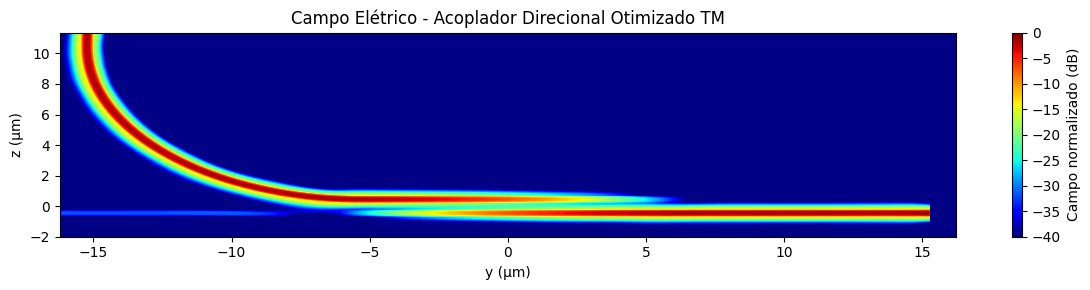

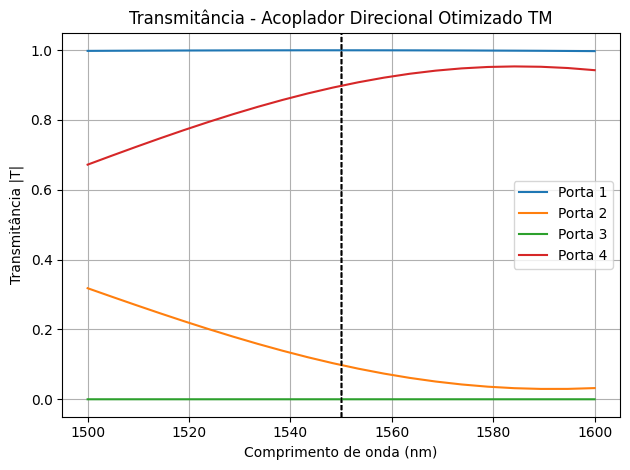

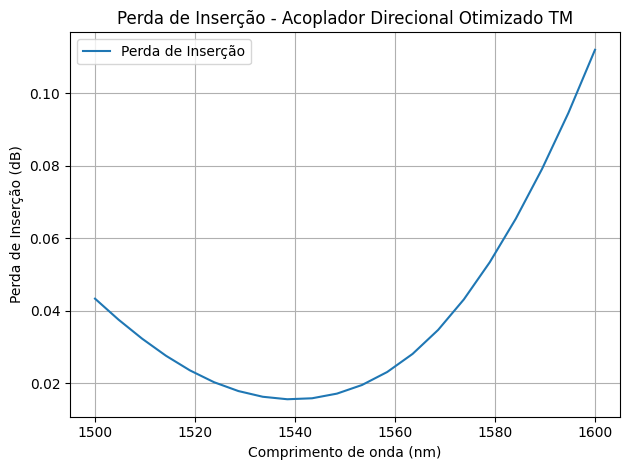

In [329]:

# Plotar campo, transmitância e perda de inserção:

with h5py.File(filename, "r") as hf:
    grp = hf["field"]
    x = grp["x"][:]
    y = grp["y"][:]
    e_field = grp["field_E"][:]
plotar_perfil_campo_dB_titulo(x, y, e_field, "Campo Elétrico - Acoplador Direcional Otimizado TM")

with h5py.File(filename, "r") as hf:
    portas = hf["portas"]
    for i in range(1, 5):
        pgrp = portas[f"porta{i}"]
        lmbd = pgrp["lambda"][:]
        T = pgrp["T"][:]
        plt.axvline(1550, color="k", linestyle="--", linewidth=1)
        plt.plot(lmbd*1e9, np.abs(T), label=f'Porta {i}')
plt.xlabel('Comprimento de onda (nm)')
plt.ylabel('Transmitância |T|')
plt.title('Transmitância - Acoplador Direcional Otimizado TM')
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()
with h5py.File(filename, "r") as hf:
    portas = hf["portas"]
    lmbd = portas["porta4"]["lambda"][:]
    T_porta4 = portas["porta4"]["T"][:]
    T_porta2 = portas["porta2"]["T"][:]
    perda_insercao = -10 * np.log10(abs(T_porta4) + abs(T_porta2))
plt.plot(lmbd*1e9, perda_insercao, label='Perda de Inserção')
plt.xlabel('Comprimento de onda (nm)')
plt.ylabel('Perda de Inserção (dB)')
plt.title('Perda de Inserção - Acoplador Direcional Otimizado TM')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()